### Hypothesis: A subset of LTRs forms epigenetically dynamic chromatin hotspots, and these hotspots are preferentially remodeled in cancer.

##### 1. Cell-type-level hotspot fraction comparison

**1-1. What fraction of LTRs are hotspots?**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from Bio import SeqIO
import plotly.graph_objects as go

# Import ChromBERT utilities
import css_utility as crb

In [2]:
# Gene annotation file (GENCODE v40)
gene_annotation = "../database/refGene.txt"

In [3]:
# CTCF union file (Liver, Lung, Blood and HepG2, A549, K562 leukemia cell lines merged)
ctcf_merged="../database/ENCODE/CTCF/CTCF_union.bed"

In [4]:
# hg38 FASTA file for sequence retrieval
fasta_path = "../database/FASTA/LTR_pm1kb_sequences.fa"

In [5]:
#### function from herv_util_test.ipynb
def load_refgene_full(gene_annotation):
    gene_df = pd.read_csv(
        gene_annotation,
        sep="\t",
        header=None,
        names=[
            "bin","name","chrom","strand",
            "txStart","txEnd",
            "cdsStart","cdsEnd",
            "exonCount","exonStarts","exonEnds",
            "score","name2","cdsStartStat","cdsEndStat","exonFrames"
        ]
    )

    # cleanup
    gene_df["txStart"] = pd.to_numeric(gene_df["txStart"], errors="coerce")
    gene_df["txEnd"] = pd.to_numeric(gene_df["txEnd"], errors="coerce")
    gene_df = gene_df.dropna(subset=["txStart","txEnd"]).copy()

    gene_df["txStart"] = gene_df["txStart"].astype(int)
    gene_df["txEnd"] = gene_df["txEnd"].astype(int)

    # add TSS
    gene_df["tss"] = np.where(
        gene_df["strand"] == "+",
        gene_df["txStart"],
        gene_df["txEnd"]
    )

    gene_df["gene_name"] = gene_df["name2"]

    return gene_df

In [6]:
gene_df=load_refgene_full(
    gene_annotation,
)
gene_df.head(10)

,bin,name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds,score,name2,cdsStartStat,cdsEndStat,exonFrames,tss,gene_name
0,585,NR_024540,chr1,-,14361,29370,29370,29370,11,"14361,14969,15795,16606,16857,17232,17605,1791...","14829,15038,15947,16765,17055,17368,17742,1806...",0,WASH7P,unk,unk,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,",29370,WASH7P
1,585,NR_106918,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-1,unk,unk,"-1,",17436,MIR6859-1
2,585,NR_107062,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-2,unk,unk,"-1,",17436,MIR6859-2
3,585,NR_107063,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-3,unk,unk,"-1,",17436,MIR6859-3
4,585,NR_128720,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-4,unk,unk,"-1,",17436,MIR6859-4
5,585,NR_036051,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-2,unk,unk,"-1,",30365,MIR1302-2
6,585,NR_036266,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-9,unk,unk,"-1,",30365,MIR1302-9
7,585,NR_036267,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-10,unk,unk,"-1,",30365,MIR1302-10
8,585,NR_036268,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-11,unk,unk,"-1,",30365,MIR1302-11
9,585,NR_026818,chr1,-,34610,36081,36081,36081,3,"34610,35276,35720,","35174,35481,36081,",0,FAM138A,unk,unk,"-1,-1,-1,",36081,FAM138A


In [ ]:
df = pd.read_csv("../processed/ltr_feature_table.csv")
print(df.shape) 
df.head()

(85363427, 28)


,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_F,frac_G,frac_H,frac_I,frac_J,frac_K,frac_L,frac_M,frac_N,frac_O
0,E001,False,chr1,20948,23075,MLT1K,2127,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,E001,False,chr1,29693,31848,MLT1A,2155,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,E001,False,chr1,29952,32131,MLT1A,2179,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,E001,False,chr1,33564,35921,MLT1J2,2357,13,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,E001,False,chr1,37255,40464,MLT1E1A-int,3209,17,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [9]:
df["n_transitions"].describe()

count    8.536343e+07
mean     3.472293e-01
std      8.006085e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.000000e+01
Name: n_transitions, dtype: float64

In [10]:
df["n_transitions"].value_counts().sort_index().head(20)

n_transitions
0     67412471
1     10225387
2      5172245
3      1579259
4       667209
5       212969
6        68340
7        18440
8         5020
9         1345
10         440
11         170
12          83
13          25
14          13
15           4
16           1
17           1
18           2
19           1
Name: count, dtype: int64

In [11]:
for t in [3,4,5]:
    n = (df["n_transitions"] >= t).sum()
    print(t, n, n/len(df))

3 2553324 0.029911217130493134
4 974065 0.011410800084209366
5 306856 0.0035947010421687967


In [13]:
df["n_transitions"].quantile(
    [0.90,0.95,0.99,0.995,0.999]
)

0.900    1.0
0.950    2.0
0.990    4.0
0.995    4.0
0.999    6.0
Name: n_transitions, dtype: float64

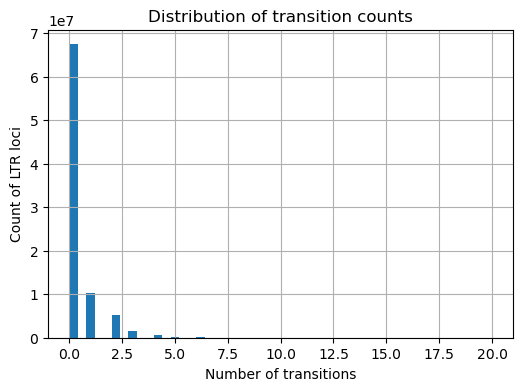

In [ ]:
plt.figure(figsize=(6,4))
df["n_transitions"].hist(bins=50)
plt.xlabel("Number of transitions")
plt.ylabel("Count of LTR loci")
plt.title("Distribution of transition counts")
plt.show()

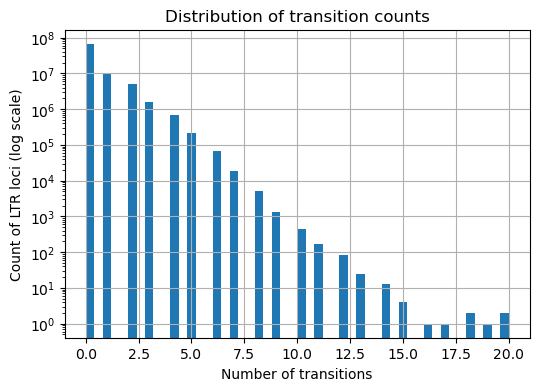

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["n_transitions"].hist(bins=50)
plt.yscale("log")
plt.xlabel("Number of transitions")
plt.ylabel("Count of LTR loci (log scale)")
plt.title("Distribution of transition counts")
plt.show()

In [14]:
# Define hotspot 
df["is_hotspot"] = df["n_transitions"] >= 4

In [15]:
# Compute fraction per cell type
summary_per_cell = (
    df.groupby("cell_id")
    .agg(
        hotspot_fraction=("is_hotspot", "mean"),
        is_cancer=("is_cancer", "first")
    )
    .reset_index()
)

print(summary_per_cell.head())

  cell_id  hotspot_fraction  is_cancer
0    E001          0.012507      False
1    E002          0.005469      False
2    E003          0.011782      False
3    E004          0.005829      False
4    E005          0.013506      False


In [16]:
# Label groups
summary_per_cell["group"] = summary_per_cell["is_cancer"].map({
    True: "Cancer",
    False: "Normal"
})

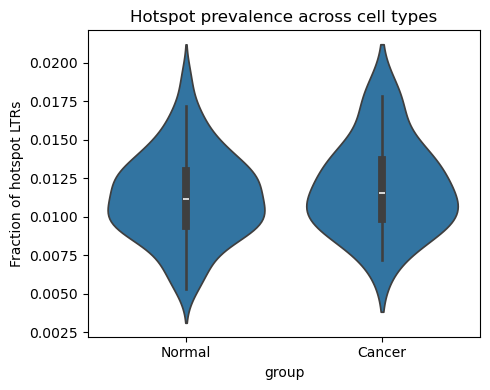

In [17]:
# Quick visualization 

plt.figure(figsize=(5,4))

sns.violinplot(
    data=summary_per_cell,
    x="group",
    y="hotspot_fraction",
    inner="box"
)

plt.ylabel("Fraction of hotspot LTRs")
plt.title("Hotspot prevalence across cell types")

plt.tight_layout()
plt.show()

In [18]:
from scipy.stats import mannwhitneyu

normal = summary_per_cell[summary_per_cell["group"]=="Normal"]["hotspot_fraction"]
cancer = summary_per_cell[summary_per_cell["group"]=="Cancer"]["hotspot_fraction"]

stat, p = mannwhitneyu(normal, cancer)

print("p-value:", p)

p-value: 0.4877743422013622


In [19]:
print(summary_per_cell.groupby("group")["hotspot_fraction"].describe())

        count      mean       std       min       25%       50%       75%  \
group                                                                       
Cancer   16.0  0.011955  0.002900  0.007168  0.009841  0.011563  0.013704   
Normal  111.0  0.011333  0.002844  0.005337  0.009407  0.011162  0.012953   

             max  
group             
Cancer  0.017861  
Normal  0.018968  


In [20]:
print(summary_per_cell.groupby("group")["hotspot_fraction"].mean())

group
Cancer    0.011955
Normal    0.011333
Name: hotspot_fraction, dtype: float64


##### For each LTR locus:
across all cell types:
 - how often is it hotspot?

In [21]:
ltr_variability = (
    df.groupby(["chrom", "start", "end", "name"])
    .agg(
        hotspot_freq=("is_hotspot", "mean"),
        n_celltypes=("is_hotspot", "size")
    )
    .reset_index()
)

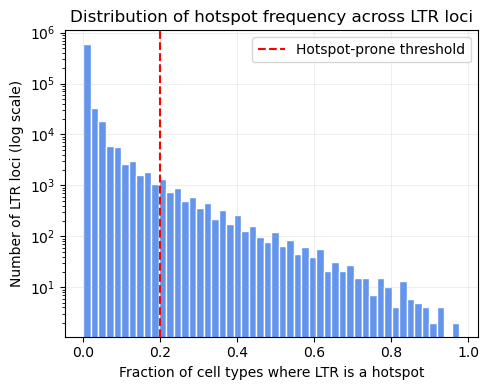

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

ltr_variability["hotspot_freq"].hist(
    bins=50,
    log=True,
    color="cornflowerblue",
    edgecolor="white"
)

plt.xlabel("Fraction of cell types where LTR is a hotspot")
plt.ylabel("Number of LTR loci (log scale)")
plt.title("Distribution of hotspot frequency across LTR loci")

plt.axvline(0.2, color="red", linestyle="--", label="Hotspot-prone threshold")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

**So...Hotspot behavior is not random—it is locus-specific and heterogeneous**

-  LTRs exhibit heterogeneous chromatin dynamics, where a subset of loci repeatedly forms transition hotspots across cell types. 
- These patterns are not captured by global or local statistical features, suggesting higher-order regulatory structure.

In [23]:
ltr_variability["is_hotspot_prone"] = ltr_variability["hotspot_freq"] > 0.2

In [24]:
df = df.merge(ltr_variability[["chrom","start","end","name","hotspot_freq"]],
              on=["chrom","start","end","name"])

# Define “hotspot-prone LTRs”
df["is_hotspot_prone"] = df["hotspot_freq"] > 0.2

In [25]:
df.groupby("is_hotspot_prone")["entropy"].mean()

is_hotspot_prone
False    0.183103
True     1.296051
Name: entropy, dtype: float64

In [26]:
# make it log scale
df["entropy_log"] = np.log10(df["entropy"] + 1e-3)

/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_46848/551533082.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


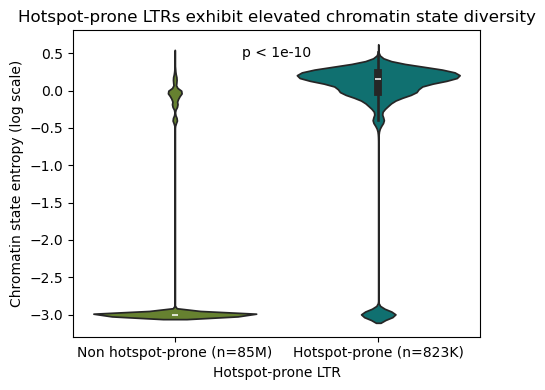

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

def format_n(n):
    if n >= 1_000_000:
        return f"{n/1_000_000:.0f}M"
    elif n >= 1_000:
        return f"{n/1_000:.0f}K"
    else:
        return str(n)

n_no = (df["is_hotspot_prone"] == False).sum()
n_yes = (df["is_hotspot_prone"] == True).sum()

palette = {
    "True": "teal",
    "False": "olivedrab"
}

plt.figure(figsize=(5,4))

sns.violinplot(
    data=df,
    x="is_hotspot_prone",
    y="entropy_log",
    palette=palette,
    inner="box"
)

plt.xlabel("Hotspot-prone LTR")
plt.ylabel("Chromatin state entropy (log scale)")
plt.title("Hotspot-prone LTRs exhibit elevated chromatin state diversity")

# plt.xticks([0,1], [f"Non hotspot-prone (n={n_no})", f"Hotspot-prone (n={n_yes})"])
plt.xticks(
    [0,1],
    [
        f"Non hotspot-prone (n={format_n(n_no)})",
        f"Hotspot-prone (n={format_n(n_yes)})"
    ]
)
plt.text(0.5, 0.45, "p < 1e-10", ha="center")

plt.tight_layout()
plt.show()

In [28]:
from scipy.stats import mannwhitneyu

group1 = df[df["is_hotspot_prone"]==False]["entropy"]
group2 = df[df["is_hotspot_prone"]==True]["entropy"]

stat, p = mannwhitneyu(group1, group2)
print("p-value:", p)

p-value: 0.0


In [29]:
df[["n_transitions", "entropy"]].corr()

,n_transitions,entropy
n_transitions,1.000000,0.911908
entropy,0.911908,1.000000


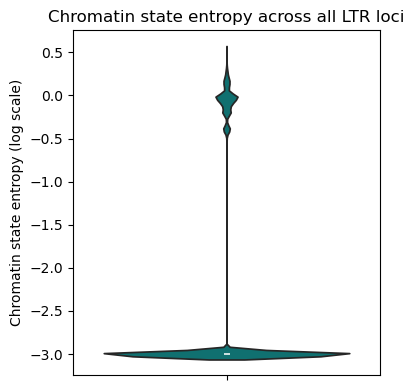

In [30]:
# entropy distribution

plt.figure(figsize=(4,4))

sns.violinplot(
    y=df["entropy_log"],
    inner="box",
    color="teal"
)

plt.ylabel("Chromatin state entropy (log scale)")
plt.title("Chromatin state entropy across all LTR loci")

plt.tight_layout()
plt.show()

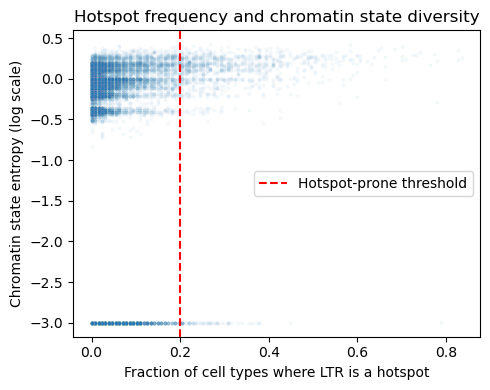

In [34]:
# entropy vs hotspot frequency 
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df.sample(min(100000, len(df)), random_state=0),
    x="hotspot_freq",
    y="entropy_log",
    alpha=0.05,
    s=8
)

plt.axvline(0.2, color="red", linestyle="--", label="Hotspot-prone threshold")
plt.xlabel("Fraction of cell types where LTR is a hotspot")
plt.ylabel("Chromatin state entropy (log scale)")
plt.title("Hotspot frequency and chromatin state diversity")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
df["hotspot_freq"].describe()
df["hotspot_freq"].quantile([0.9, 0.95, 0.99, 0.995, 0.999])

0.900    0.023622
0.950    0.047244
0.990    0.196850
0.995    0.275591
0.999    0.488189
Name: hotspot_freq, dtype: float64

In [37]:
print((df["hotspot_freq"] >= 0.2).mean())
print((df["hotspot_freq"] >= 0.2).sum())

0.00963910457812337
822827


In [38]:
from scipy.stats import spearmanr

spearmanr(df["hotspot_freq"],df["entropy_log"])

SignificanceResult(statistic=np.float64(0.3288629510204673), pvalue=np.float64(0.0))

<Axes: xlabel='n_transitions', ylabel='entropy'>

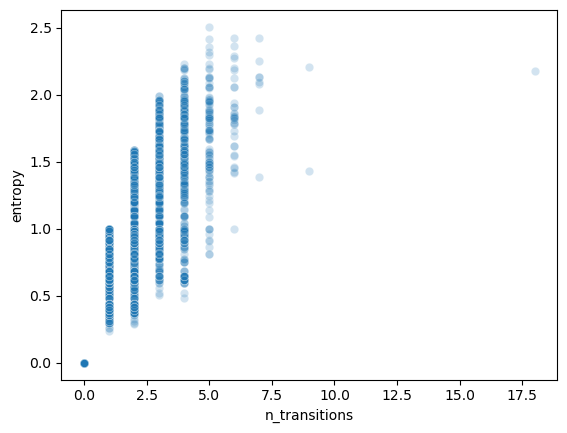

In [29]:
sns.scatterplot(
    data=df.sample(50000),
    x="n_transitions",
    y="entropy",
    alpha=0.2
)

In [32]:
df["entropy_norm"] = df["entropy"] / np.log(df["n_unique_states"].clip(lower=2))

In [33]:
df.head()

,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_L,frac_M,frac_N,frac_O,is_hotspot,hotspot_freq_x,is_hotspot_prone,hotspot_freq_y,hotspot_freq,entropy_norm
0,E001,False,chr1,20948,23075,MLT1K,2127,12,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
1,E001,False,chr1,29693,31848,MLT1A,2155,12,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
2,E001,False,chr1,29952,32131,MLT1A,2179,12,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
3,E001,False,chr1,33564,35921,MLT1J2,2357,13,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0
4,E001,False,chr1,37255,40464,MLT1E1A-int,3209,17,1.0,0,...,0.0,0.0,0.0,1.0,False,0.0,False,0.0,0.0,-0.0


##### 2. State/category enrichment in hotspot vs non-hotspot

- Are recurrent hotspot-prone LTRs enriched for specific chromatin-state categories beyond ordinary hotspot behavior?

In [396]:
# per locus recurrence table
ltr_variability = (
    df.groupby(["chrom", "start", "end", "name"])["is_hotspot"]
    .mean()
    .reset_index(name="hotspot_freq")
)

ltr_variability["is_hotspot_prone"] = ltr_variability["hotspot_freq"] >= 0.2

# merge recurrence back
df2 = df.merge(
    ltr_variability[["chrom", "start", "end", "name", "hotspot_freq", "is_hotspot_prone"]],
    on=["chrom", "start", "end", "name"],
    how="left"
)

In [402]:
# how many is_hotspot_prone==True when state_category==Quiescent
quiescent_hotspot_prone = df2[
    (df2["state_category"] == "Quiescent") &
    (df2["is_hotspot_prone"] == True)
]
quiescent_hotspot_prone.head()

,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,nearest_tss,tss_distance,tss_bin,ctcf_overlap,GC,CpG_count,CpG_density,N_fraction,hotspot_freq,is_hotspot_prone
2211,E001,False,chr1,9087810,9095338,HERVFH19-int,7528,38,0.789474,2,...,9072259,15551,10kb-20kb,False,0.452046,87,0.011557,0.0,0.440945,True
7009,E001,False,chr1,30921069,30923980,MER34B-int,2911,15,0.666667,1,...,30935776,11796,10kb-20kb,False,0.351082,23,0.007901,0.0,0.236220,True
8599,E001,False,chr1,38216960,38219611,MLT2F,2651,15,1.000000,0,...,38214767,2193,1kb-5kb,False,0.513014,27,0.010185,0.0,0.220472,True
12057,E001,False,chr1,54912818,54919793,HERV17-int,6975,35,1.000000,0,...,54887195,25623,>20kb,False,0.461792,79,0.011326,0.0,0.283465,True
14390,E001,False,chr1,64185957,64193253,HERVL18-int,7296,38,0.657895,2,...,64203622,10369,10kb-20kb,False,0.493010,87,0.011924,0.0,0.503937,True


In [403]:
len(quiescent_hotspot_prone)

53334

In [ ]:
category_order = ["Active", "Repressed", "Bivalent", "Mixed", "Quiescent"]

bg_all = (
    df2["state_category"]
    .value_counts(normalize=True)
    .reindex(category_order, fill_value=0)
)

bg_hotspot = (
    df2[df2["is_hotspot"]]["state_category"]
    .value_counts(normalize=True)
    .reindex(category_order, fill_value=0)
)

# When hotspot-prone loci are acting as hotspots, what states are they in?
target = (
    df2[
        (df2["is_hotspot_prone"]) &
        (df2["is_hotspot"])
    ]["state_category"]
    .value_counts(normalize=True)
    .reindex(category_order, fill_value=0)
)

enrich_vs_all = np.log2((target + 1e-9) / (bg_all + 1e-9))
enrich_vs_hotspot = np.log2((target + 1e-9) / (bg_hotspot + 1e-9))

In [407]:
target_counts = (
    df2[
        (df2["is_hotspot_prone"]) &
        (df2["is_hotspot"])
    ]["state_category"]
    .value_counts()
    .reindex(category_order, fill_value=0)
)

print(target_counts)
print(enrich_vs_hotspot)

state_category
Active       170553
Repressed     30406
Bivalent      33578
Mixed         27246
Quiescent      3091
Name: count, dtype: int64
state_category
Active      -0.096185
Repressed    0.018857
Bivalent     1.065538
Mixed        0.202067
Quiescent   -2.052584
Name: proportion, dtype: float64


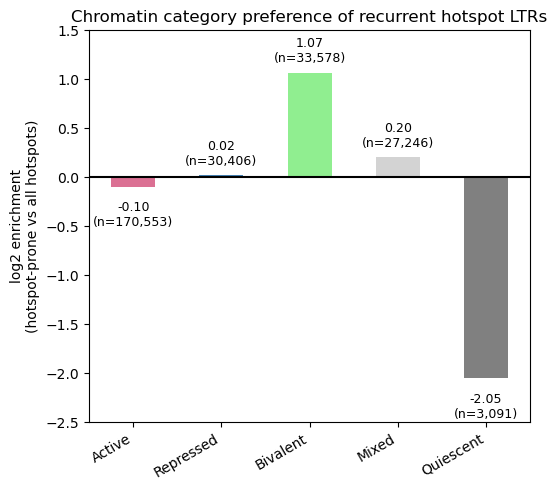

In [430]:
plt.figure(figsize=(5.5,5))

ax = enrich_vs_hotspot.plot(
    kind="bar",
    color=[color_dict[c] for c in category_order]
)

plt.axhline(0, color="black")
plt.ylabel("log2 enrichment\n(hotspot-prone vs all hotspots)")
plt.xlabel("")
plt.title("Chromatin category preference of recurrent hotspot LTRs")
plt.xticks(rotation=30, ha="right")

for i, (cat, val) in enumerate(enrich_vs_hotspot.items()):
    n = target_counts[cat]

    ax.text(
        i,
        val + (0.08 if val >= 0 else -0.15),
        f"{val:.2f}\n(n={n:,})",
        ha="center",
        va="bottom" if val >= 0 else "top",
        fontsize=9
    )

plt.ylim(-2.5, 1.5)
plt.tight_layout()
plt.show()

33,578 is likely “entries,” not unique loci

because each LTR locus appears across many cell types. So first I’d separate:

- Bivalent recurrent-hotspot entries = cell-specific instances
- Bivalent recurrent-hotspot loci = unique genomic LTR loci

In [431]:
biv_recurrent_hotspot = df2[
    (df2["is_hotspot_prone"]) &
    (df2["is_hotspot"]) &
    (df2["state_category"] == "Bivalent")
].copy()

biv_loci = biv_recurrent_hotspot[
    ["chrom", "start", "end", "name"]
].drop_duplicates()

print("entries:", len(biv_recurrent_hotspot))
print("unique loci:", len(biv_loci))

entries: 33578
unique loci: 3449


In [432]:
# A. What do their chromatin sequences look like?
biv_recurrent_hotspot[
    ["cell_id", "chrom", "start", "end", "name", "state_seq_full_slice", "n_transitions", "entropy"]
].sample(10, random_state=1)

,cell_id,chrom,start,end,name,state_seq_full_slice,n_transitions,entropy
73382276,E112,chr2,130448340,130450477,THE1D-int,MLLLMMMMJKKK,4,1.825011
49665213,E076,chr18,28689435,28692159,MER72,MKJJJKKJJJJKKJ,6,1.263809
24799914,E037,chr19,28431265,28436349,HERVH-int,AKKJLLLLLLLLLLLLLLLLMMMMMM,4,1.565448
73482190,E112,chr4,87276627,87278827,MLT1J2,MMMJKKJJJJJK,4,1.500000
11683032,E018,chr6,3166304,3171584,HERVH-int,AAAAJJJJJJKJKKAAAAAAJJJKMMM,8,1.821797
39903576,E061,chr5,72948682,72950878,MamGypLTR3,NMLLKKKJJJKA,6,2.355389
29601494,E045,chr1,46783142,46785466,MER4-int,NNNMMMJJJKJKL,6,2.199688
59472304,E091,chr7,1647624,1650007,MLT1B,MMLLLLMLLLLMM,4,0.961237
66990246,E102,chr10,87245624,87248009,MLT1D,NNNJJJJJJJKLM,4,1.823026
47755437,E074,chr1,28402104,28404518,LTR16A,JLKKMMMJKJJJJ,6,1.775859


In [433]:
# B. What states compose them?
state_cols = [f"frac_{s}" for s in list("ABCDEFGHIJKLMNO")]

mean_state_comp = biv_recurrent_hotspot[state_cols].mean()
mean_state_comp

frac_A    0.020133
frac_B    0.013772
frac_C    0.000468
frac_D    0.000577
frac_E    0.005507
frac_F    0.000386
frac_G    0.009652
frac_H    0.000283
frac_I    0.000386
frac_J    0.198538
frac_K    0.296226
frac_L    0.230470
frac_M    0.170391
frac_N    0.049509
frac_O    0.003701
dtype: float64

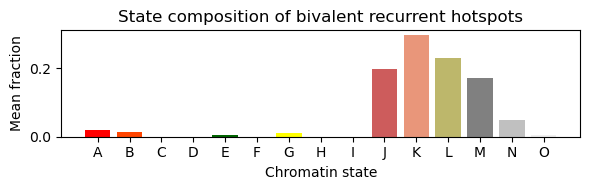

In [450]:
state_order = list("ABCDEFGHIJKLMNO")
colors = [crb.state_col_dict_num[k] for k in state_order]

plt.figure(figsize=(6,2))   
plt.bar(
    state_order,
    [mean_state_comp[f"frac_{s}"] for s in state_order],
    color=colors
)   
plt.ylabel("Mean fraction")
plt.xlabel("Chromatin state")
plt.title("State composition of bivalent recurrent hotspots")
plt.tight_layout()
plt.show()

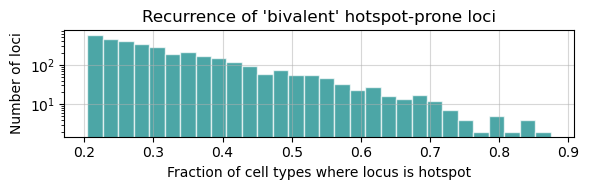

In [451]:
# C. Are these loci recurrent because of many cells or a few cell types?
biv_loci_freq = biv_loci.merge(
    ltr_variability[["chrom", "start", "end", "name", "hotspot_freq"]],
    on=["chrom", "start", "end", "name"],
    how="left"
)

plt.figure(figsize=(6,2))  
biv_loci_freq["hotspot_freq"].hist(bins=30, log=True, color="teal",alpha=0.7, edgecolor="white")
plt.xlabel("Fraction of cell types where locus is hotspot")
plt.ylabel("Number of loci")
plt.title("Recurrence of 'bivalent' hotspot-prone loci")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

##### 3. Three pairs: Do hotspot-prone LTRs undergo systematic remodeling during cancer transition?

In [47]:
import pandas as pd

df = pd.read_csv("../processed/ltr_feature_table.csv")
df["is_hotspot"] = df["n_transitions"] >= 4

In [48]:
df_pair = df[[
    "cell_id", "chrom", "start", "end", "name", "is_hotspot"
]].copy()

In [49]:
pairs = {
    "liver": ("E066", "E118"),
    "lung": ("E096", "E114"),
    "blood": ("E029", "E123"),
}

In [50]:
def make_hotspot_transition_table(df_pair, normal_id, cancer_id):
    df_normal = (
        df_pair[df_pair["cell_id"] == normal_id]
        .drop(columns=["cell_id"])
        .rename(columns={"is_hotspot": "hotspot_normal"})
    )

    df_cancer = (
        df_pair[df_pair["cell_id"] == cancer_id]
        .drop(columns=["cell_id"])
        .rename(columns={"is_hotspot": "hotspot_cancer"})
    )

    merged = df_normal.merge(
        df_cancer,
        on=["chrom", "start", "end", "name"],
        how="inner"
    )

    transition_table = pd.crosstab(
        merged["hotspot_normal"],
        merged["hotspot_cancer"]
    )

    transition_table.index = ["non-hotspot", "hotspot"]
    transition_table.columns = ["non-hotspot", "hotspot"]

    return merged, transition_table

In [51]:
merged_liver, table_liver = make_hotspot_transition_table(df_pair, "E066", "E118")
table_liver

,non-hotspot,hotspot
non-hotspot,654417,10267
hotspot,6085,1745


In [52]:
results = {}

for tissue, (normal_id, cancer_id) in pairs.items():
    merged, table = make_hotspot_transition_table(df_pair, normal_id, cancer_id)
    results[tissue] = {"merged": merged, "table": table}
    print(f"\n{tissue.upper()} ({normal_id} -> {cancer_id})")
    print(table)


LIVER (E066 -> E118)
             non-hotspot  hotspot
non-hotspot       654417    10267
hotspot             6085     1745

LUNG (E096 -> E114)
             non-hotspot  hotspot
non-hotspot       657114     8561
hotspot             6147      695

BLOOD (E029 -> E123)
             non-hotspot  hotspot
non-hotspot       650998     7139
hotspot             5669      849


In [53]:
# Row-normalized
for tissue in results:
    table = results[tissue]["table"]
    prop = table.div(table.sum(axis=1), axis=0)
    results[tissue]["prop_row"] = prop

    print(f"\n{tissue.upper()} row-normalized")
    print(prop)


LIVER row-normalized
             non-hotspot   hotspot
non-hotspot     0.984554  0.015446
hotspot         0.777139  0.222861

LUNG row-normalized
             non-hotspot   hotspot
non-hotspot     0.987139  0.012861
hotspot         0.898422  0.101578

BLOOD row-normalized
             non-hotspot   hotspot
non-hotspot     0.989153  0.010847
hotspot         0.869745  0.130255


In [54]:
def transition_labels(merged):
    out = merged.copy()
    out["transition"] = (
        out["hotspot_normal"].map({False: "non-hotspot", True: "hotspot"})
        + " → " +
        out["hotspot_cancer"].map({False: "non-hotspot", True: "hotspot"})
    )
    return out

liver_labeled = transition_labels(results["liver"]["merged"])
liver_labeled["transition"].value_counts()

transition
non-hotspot → non-hotspot    654417
non-hotspot → hotspot         10267
hotspot → non-hotspot          6085
hotspot → hotspot              1745
Name: count, dtype: int64

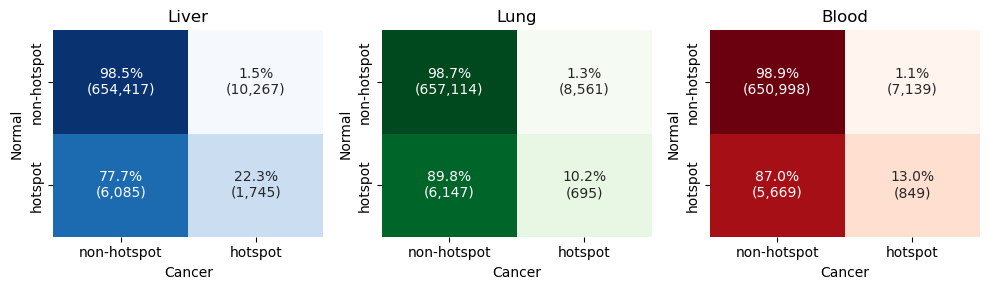

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(10,3))

# define colormap per tissue
cmap_dict = {
    "liver": "Blues",
    "lung": "Greens",
    "blood": "Reds"
}

for ax, (tissue, res) in zip(axes, results.items()):

    # build annotation: percentage (%) + count
    annot = res["prop_row"].copy().astype(str)

    for i in range(res["prop_row"].shape[0]):
        for j in range(res["prop_row"].shape[1]):
            p = res["prop_row"].iloc[i, j] * 100  # convert to %
            c = res["table"].iloc[i, j]          # raw count
            annot.iloc[i, j] = f"{p:.1f}%\n({c:,})"

    sns.heatmap(
        res["prop_row"],
        annot=annot,
        fmt="",
        cmap=cmap_dict[tissue],
        vmin=0,
        vmax=1,
        cbar=False,
        ax=ax
    )

    ax.set_title(tissue.capitalize())
    ax.set_xlabel("Cancer")
    ax.set_ylabel("Normal")

plt.tight_layout()
plt.show()

#### Among LTRs that are hotspots in normal and become non-hotspot in cancer, what chromatin state category do they resolve into?

In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# load
df_features = pd.read_csv("../processed/ltr_feature_table.csv")
df_seq = pd.read_csv("../processed/ltr_sequences.csv")

# merge
df = df_features.merge(
    df_seq,
    on=["cell_id", "is_cancer", "chrom", "start", "end", "name"],
    how="inner"
)

print(df.shape)

(85363427, 29)


In [95]:
df["is_hotspot"] = df["n_transitions"] >= 4

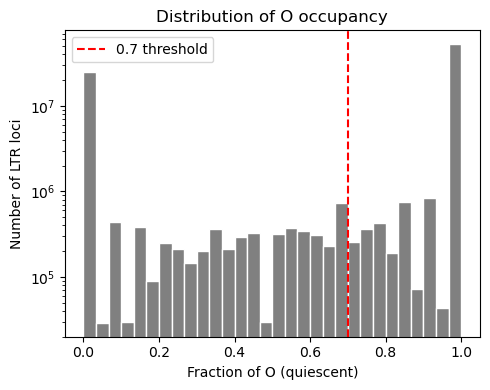

In [191]:
# overall distribution of O ratio

import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.hist(df["O_ratio"], bins=30, color="gray", edgecolor="white", log=True)
plt.axvline(0.7, color="red", linestyle="--", label="0.7 threshold")

plt.xlabel("Fraction of O (quiescent)")
plt.ylabel("Number of LTR loci")
plt.title("Distribution of O occupancy")

plt.legend()
plt.tight_layout()
plt.show()

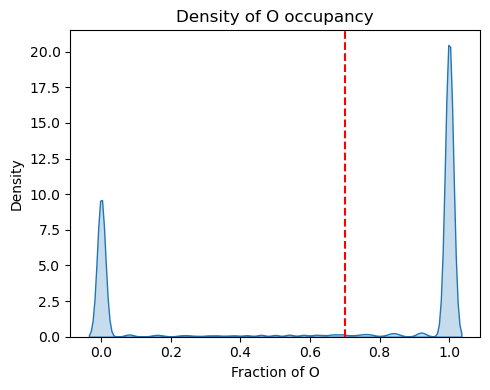

In [192]:
plt.figure(figsize=(5,4))

sns.kdeplot(data=df, x="O_ratio", fill=True)

plt.axvline(0.7, color="red", linestyle="--")

plt.xlabel("Fraction of O")
plt.title("Density of O occupancy")

plt.tight_layout()
plt.show()

In [196]:
# active_states = set("ABCDEFG")
# repressed_states = set("HIMN")
# # # repressed_states = set("HIMNO")
# bivalent_states = set("JKL")

# def classify_state_category(seq):
#     if pd.isna(seq) or len(seq) == 0:
#         return np.nan
    
#     # Check if O-only
#     if set(seq) == {"O"}:
#         return "Quiescent"
    
#     # Remove O for classification
#     seq = [ch for ch in seq if ch != "O"]
    
#     if len(seq) == 0:
#         return "Quiescent"
    
#     total = len(seq)
    
#     frac_active = sum(ch in active_states for ch in seq) / total
#     frac_repressed = sum(ch in repressed_states for ch in seq) / total
#     frac_bivalent = sum(ch in bivalent_states for ch in seq) / total
    
#     if frac_active > 0.5:
#         return "Active"
#     elif frac_repressed > 0.5:
#         return "Repressed"
#     elif frac_bivalent > 0.5:
#         return "Bivalent"
#     else:
#         return "Mixed"

active_states = set("ABCDEFG")
repressed_states = set("HIMN")
# # repressed_states = set("HIMNO")
bivalent_states = set("JKL")

def classify_state_category(seq):
    if pd.isna(seq) or len(seq) == 0:
        return np.nan
    
    total = len(seq)
    
    frac_O = seq.count("O") / total
    
    # 🥇 Step 1: quiescent filter
    if frac_O > 0.6:   # you can tune 0.6–0.8
        return "Quiescent"
    
    # 🥈 Step 2: compute fractions (including O in denominator)
    frac_active = sum(ch in active_states for ch in seq) / total
    frac_repressed = sum(ch in repressed_states for ch in seq) / total
    frac_bivalent = sum(ch in bivalent_states for ch in seq) / total
    
    if frac_active > 0.5:
        return "Active"
    elif frac_repressed > 0.5:
        return "Repressed"
    elif frac_bivalent > 0.5:
        return "Bivalent"
    else:
        return "Mixed"

In [197]:
df["state_category"] = df["state_seq_full_slice"].apply(classify_state_category)

In [198]:
df.tail(100)

,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_I,frac_J,frac_K,frac_L,frac_M,frac_N,frac_O,state_seq_full_slice,is_hotspot,state_category
85363327,E129,True,chrY,24582681,24585035,MER61-int,2354,13,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,OOOOOOOOOOOOO,False,Quiescent
85363328,E129,True,chrY,24583128,24587734,MER61-int,4606,24,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,OOOOOOOOOOOOOOOOOOOOOOOO,False,Quiescent
85363329,E129,True,chrY,24608476,24610995,LTR22,2519,13,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,OOOOOOOOOOOOO,False,Quiescent
85363330,E129,True,chrY,24651257,24654351,MER11B,3094,16,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,OOOOOOOOOOOOOOOO,False,Quiescent
85363331,E129,True,chrY,24661957,24664113,LTR32,2156,12,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,OOOOOOOOOOOO,False,Quiescent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85363422,E129,True,chrY,25239006,25241335,MER66-int,2329,12,0.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,IIIIIIIIIIII,False,Repressed
85363423,E129,True,chrY,25239335,25241651,MER66B,2316,13,0.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,IIIIIIIIIIIII,False,Repressed
85363424,E129,True,chrY,25239698,25242327,LTR12D,2629,14,0.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,IIIIIIIIIIIIII,False,Repressed
85363425,E129,True,chrY,25240331,25242491,LTR12D,2160,12,0.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,IIIIIIIIIIII,False,Repressed


In [199]:
df_partial_O = df[
    df["state_seq_full_slice"].str.contains("O", na=False) &
    (df["state_seq_full_slice"].str.replace("O", "", regex=False).str.len() > 0)
]

In [200]:
df_partial_O

,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_I,frac_J,frac_K,frac_L,frac_M,frac_N,frac_O,state_seq_full_slice,is_hotspot,state_category
117,E001,False,chr1,407238,409396,MLT1I,2158,11,0.909091,2,...,0.090909,0.0000,0.0,0.0,0.00,0.0,0.909091,OOOIOOOOOOO,False,Quiescent
118,E001,False,chr1,407459,409522,MLT1I,2063,11,0.909091,2,...,0.090909,0.0000,0.0,0.0,0.00,0.0,0.909091,OOIOOOOOOOO,False,Quiescent
162,E001,False,chr1,598078,600158,MLT1F1,2080,11,0.727273,1,...,0.000000,0.0000,0.0,0.0,0.00,0.0,0.727273,OOOOOOOOAAA,False,Quiescent
166,E001,False,chr1,615790,617961,MLT1K,2171,12,0.916667,1,...,0.000000,0.0000,0.0,0.0,0.00,0.0,0.916667,OOOOOOOOOOOG,False,Quiescent
167,E001,False,chr1,616973,619322,MER4E1,2349,13,0.384615,3,...,0.000000,0.0000,0.0,0.0,0.00,0.0,0.384615,OOOOOGGGEEGGG,False,Active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85361300,E129,True,chrY,17518775,17521733,PRIMA41-int,2958,16,0.687500,2,...,0.000000,0.0625,0.0,0.0,0.25,0.0,0.687500,MMMMJOOOOOOOOOOO,False,Quiescent
85363387,E129,True,chrY,25086531,25089107,LTR22,2576,14,0.928571,2,...,0.071429,0.0000,0.0,0.0,0.00,0.0,0.928571,OOOOOOOOIOOOOO,False,Quiescent
85363388,E129,True,chrY,25087109,25089782,HERVK22-int,2673,14,0.928571,2,...,0.071429,0.0000,0.0,0.0,0.00,0.0,0.928571,OOOOOIOOOOOOOO,False,Quiescent
85363389,E129,True,chrY,25088189,25091989,HERVK22-int,3800,20,0.950000,1,...,0.050000,0.0000,0.0,0.0,0.00,0.0,0.950000,IOOOOOOOOOOOOOOOOOOO,False,Quiescent


In [201]:
pairs = {
    "Liver": ("E066", "E118"),
    "Lung": ("E096", "E114"),
    "Blood": ("E029", "E123"),
}

In [202]:
records = []

for tissue, (normal_id, cancer_id) in pairs.items():
    df_normal = (
        df[df["cell_id"] == normal_id][
            ["chrom", "start", "end", "name", "is_hotspot", "state_category"]
        ]
        .rename(columns={
            "is_hotspot": "hotspot_normal",
            "state_category": "category_normal"
        })
    )

    df_cancer = (
        df[df["cell_id"] == cancer_id][
            ["chrom", "start", "end", "name", "is_hotspot", "state_category"]
        ]
        .rename(columns={
            "is_hotspot": "hotspot_cancer",
            "state_category": "category_cancer"
        })
    )

    merged = df_normal.merge(
        df_cancer,
        on=["chrom", "start", "end", "name"],
        how="inner"
    )

    # keep only resolving hotspots
    resolving = merged[
        (merged["hotspot_normal"] == True) &
        (merged["hotspot_cancer"] == False)
    ].copy()

    resolving["tissue"] = tissue
    records.append(resolving)

df_resolving = pd.concat(records, ignore_index=True)
print(df_resolving.shape)
df_resolving.head()

(17901, 9)


,chrom,start,end,name,hotspot_normal,category_normal,hotspot_cancer,category_cancer,tissue
0,chr1,732909,735062,LTR41,True,Active,False,Active,Liver
1,chr1,887956,890347,MSTD,True,Active,False,Active,Liver
2,chr1,888927,890998,MLT1I,True,Active,False,Active,Liver
3,chr1,1171049,1173409,MLT1D,True,Active,False,Bivalent,Liver
4,chr1,2351202,2353368,MLT1J,True,Active,False,Active,Liver


In [203]:
fate_counts = (
    df_resolving.groupby(["tissue", "category_cancer"])
    .size()
    .reset_index(name="count")
)

print(fate_counts)

   tissue category_cancer  count
0   Blood          Active   2998
1   Blood        Bivalent      1
2   Blood           Mixed    122
3   Blood       Quiescent   1554
4   Blood       Repressed    994
5   Liver          Active   3168
6   Liver        Bivalent    367
7   Liver           Mixed    277
8   Liver       Quiescent   1129
9   Liver       Repressed   1144
10   Lung          Active   2897
11   Lung        Bivalent     91
12   Lung           Mixed    147
13   Lung       Quiescent   1871
14   Lung       Repressed   1141


In [204]:
fate_props = fate_counts.copy()
fate_props["fraction"] = fate_props.groupby("tissue")["count"].transform(lambda x: x / x.sum())

print(fate_props)

   tissue category_cancer  count  fraction
0   Blood          Active   2998  0.528841
1   Blood        Bivalent      1  0.000176
2   Blood           Mixed    122  0.021521
3   Blood       Quiescent   1554  0.274122
4   Blood       Repressed    994  0.175340
5   Liver          Active   3168  0.520624
6   Liver        Bivalent    367  0.060312
7   Liver           Mixed    277  0.045522
8   Liver       Quiescent   1129  0.185538
9   Liver       Repressed   1144  0.188003
10   Lung          Active   2897  0.471287
11   Lung        Bivalent     91  0.014804
12   Lung           Mixed    147  0.023914
13   Lung       Quiescent   1871  0.304376
14   Lung       Repressed   1141  0.185619


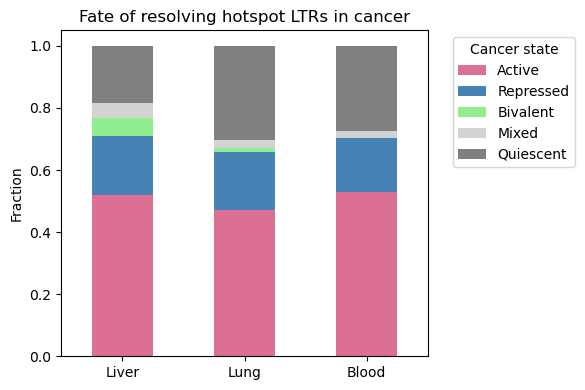

In [262]:
category_order = ["Active", "Repressed", "Bivalent", "Mixed", "Quiescent"]

plot_df = (
    fate_props.pivot(index="tissue", columns="category_cancer", values="fraction")
    .reindex(columns=category_order)
    .fillna(0)
)

color_dict = {
    "Active": "palevioletred",     # 
    "Repressed": "steelblue",  # 
    "Bivalent": "lightgreen",   # 
    "Mixed": "lightgray",   #
    "Quiescent": "gray"       # 
}

plot_df = plot_df.reindex(["Liver", "Lung", "Blood"])

plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4),
    color=[color_dict[c] for c in plot_df.columns]
)

plt.ylabel("Fraction")
plt.xlabel("")
plt.title("Fate of resolving hotspot LTRs in cancer")

plt.xticks(rotation=0)  # cleaner for slides

plt.legend(title="Cancer state", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [207]:
summary_table = fate_counts.merge(
    fate_props[["tissue", "category_cancer", "fraction"]],
    on=["tissue", "category_cancer"]
)

summary_table["percent"] = summary_table["fraction"] * 100
print(summary_table.sort_values(["tissue", "category_cancer"]))

   tissue category_cancer  count  fraction    percent
0   Blood          Active   2998  0.528841  52.884107
1   Blood        Bivalent      1  0.000176   0.017640
2   Blood           Mixed    122  0.021521   2.152055
3   Blood       Quiescent   1554  0.274122  27.412242
4   Blood       Repressed    994  0.175340  17.533957
5   Liver          Active   3168  0.520624  52.062449
6   Liver        Bivalent    367  0.060312   6.031224
7   Liver           Mixed    277  0.045522   4.552177
8   Liver       Quiescent   1129  0.185538  18.553821
9   Liver       Repressed   1144  0.188003  18.800329
10   Lung          Active   2897  0.471287  47.128681
11   Lung        Bivalent     91  0.014804   1.480397
12   Lung           Mixed    147  0.023914   2.391410
13   Lung       Quiescent   1871  0.304376  30.437612
14   Lung       Repressed   1141  0.185619  18.561900


In [ ]:
# restrict to the same 3 normal tissues
normal_ids = ["E066", "E096", "E029"]  # liver, lung, blood

df_normal_subset = df[
    (df["is_cancer"] == False) &
    (df["cell_id"].isin(normal_ids))
]

# background
bg_counts = df_normal_subset["state_category"].value_counts()
bg_frac = bg_counts / bg_counts.sum()

# resolving (normal side)
res_counts = df_resolving["category_normal"].value_counts()
res_frac = res_counts / res_counts.sum()

# enrichment
enrichment = (res_frac / bg_frac).apply(np.log2)
print(enrichment)

Active       1.801779
Bivalent     5.048741
Mixed        2.132036
Quiescent   -3.183279
Repressed   -0.529284
Name: count, dtype: float64


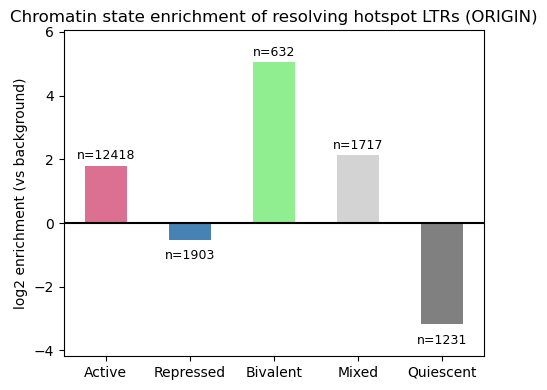

In [257]:
# make sure order is consistent
enrichment = enrichment.reindex(["Active", "Repressed", "Bivalent", "Mixed", "Quiescent"])
res_counts = res_counts.reindex(enrichment.index)  # align counts

plt.figure(figsize=(5,4))

ax = enrichment.plot(
    kind="bar",
    color=[
        "palevioletred",  # Active
        "steelblue",      # Repressed
        "lightgreen",     # Bivalent
        "lightgray",      # Mixed
        "gray"            # Quiescent
    ]
)

plt.axhline(0, color="black")

plt.ylabel("log2 enrichment (vs background)")
plt.ylim(enrichment.min() - 1, enrichment.max() + 1)
plt.title("Chromatin state enrichment of resolving hotspot LTRs (ORIGIN)")

plt.xticks(rotation=0)

# add count labels
for i, (val, cnt) in enumerate(zip(enrichment, res_counts)):
    ax.text(
        i,
        val + (0.1 if val >= 0 else -0.3),  # position above/below bar
        f"n={cnt}",
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [265]:
pairs = {
    "Liver": ("E066", "E118"),
    "Lung": ("E096", "E114"),
    "Blood": ("E029", "E123"),
}

In [270]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

category_order = ["Active", "Repressed", "Bivalent", "Mixed", "Quiescent"]

results_cat = {}

for tissue, (normal_id, cancer_id) in pairs.items():
    df_normal = (
        df[df["cell_id"] == normal_id][
            ["chrom", "start", "end", "name", "is_hotspot", "state_category"]
        ]
        .rename(columns={
            "is_hotspot": "hotspot_normal",
            "state_category": "category_normal"
        })
    )

    df_cancer = (
        df[df["cell_id"] == cancer_id][
            ["chrom", "start", "end", "name", "is_hotspot", "state_category"]
        ]
        .rename(columns={
            "is_hotspot": "hotspot_cancer",
            "state_category": "category_cancer"
        })
    )

    merged = df_normal.merge(
        df_cancer,
        on=["chrom", "start", "end", "name"],
        how="inner"
    )

    # restrict to normal hotspots only
    hotspot_only = merged[merged["hotspot_normal"] == True].copy()

    # # category transition heatmap only for hotspots that disappear in cancer
    # hotspot_only = merged[
    # (merged["hotspot_normal"] == True) &
    # (merged["hotspot_cancer"] == False)
    # ].copy()

    # count transitions
    table_counts = pd.crosstab(
        hotspot_only["category_normal"],
        hotspot_only["category_cancer"]
    ).reindex(index=category_order, columns=category_order, fill_value=0)

    # row-normalized
    table_props = table_counts.div(table_counts.sum(axis=1), axis=0).fillna(0)

    results_cat[tissue] = {
        "counts": table_counts,
        "props": table_props,
        "merged": hotspot_only
    }

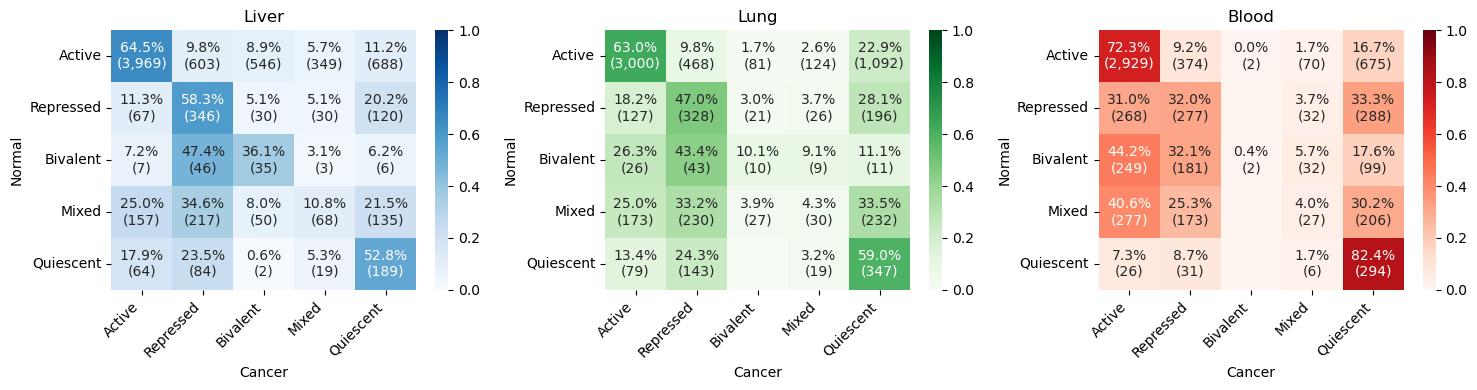

In [278]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cmap_dict = {
    "Liver": "Blues",
    "Lung": "Greens",
    "Blood": "Reds"
}

for ax, tissue in zip(axes, ["Liver", "Lung", "Blood"]):
    props = results_cat[tissue]["props"]
    counts = results_cat[tissue]["counts"]

    # annotation = percent + count
    annot = props.copy().astype(str)
    for i in range(props.shape[0]):
        for j in range(props.shape[1]):
            p = props.iloc[i, j] * 100
            c = counts.iloc[i, j]
            annot.iloc[i, j] = f"{p:.1f}%\n({c:,})" if c > 0 else ""

    sns.heatmap(
        props,
        annot=annot,
        fmt="",
        cmap=cmap_dict[tissue],
        vmin=0,
        vmax=1,
        cbar=True,
        ax=ax
    )

    ax.set_title(tissue)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("Cancer")
    ax.set_ylabel("Normal")

plt.tight_layout()
plt.show()

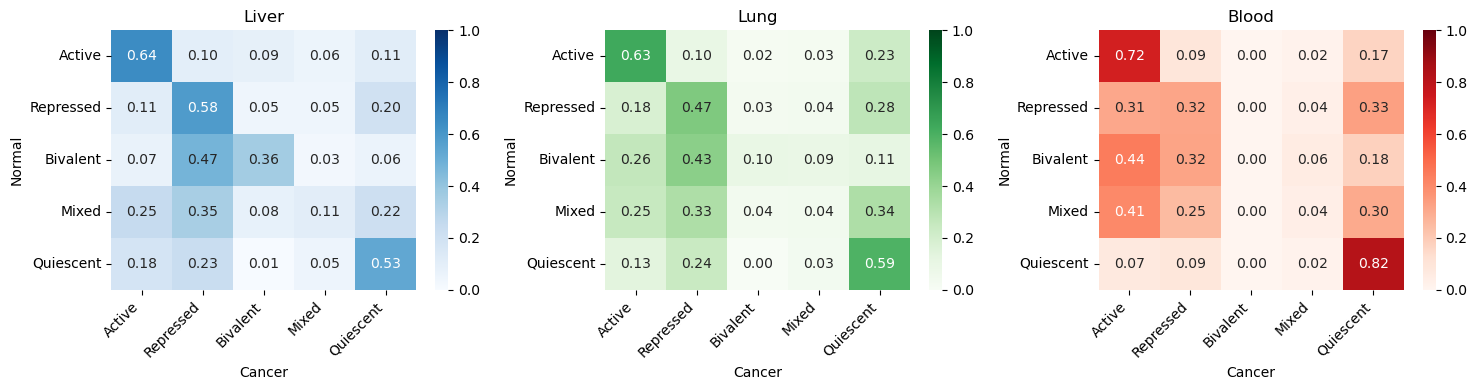

In [279]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, tissue in zip(axes, ["Liver", "Lung", "Blood"]):
    sns.heatmap(
        results_cat[tissue]["props"],
        annot=True,
        fmt=".2f",
        cmap=cmap_dict[tissue],
        vmin=0,
        vmax=1,
        cbar=True,
        ax=ax
    )
    ax.set_title(tissue)
    ax.set_xlabel("Cancer")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_ylabel("Normal")

plt.tight_layout()
plt.show()

In [454]:
pairs = {
    "Liver": ("E066", "E118"),
    "Lung": ("E096", "E114"),
    "Blood": ("E029", "E123"),
}

for tissue, (normal_id, cancer_id) in pairs.items():

    sub_normal = df2[df2["cell_id"] == normal_id]
    sub_cancer = df2[df2["cell_id"] == cancer_id]

    merged = sub_normal.merge(
        sub_cancer,
        on=["chrom", "start", "end", "name"],
        suffixes=("_normal", "_cancer")
    )

    print(tissue, merged.shape)

Liver (672514, 82)
Lung (672517, 82)
Blood (664655, 82)


In [456]:
merged.head()

,chrom,start,end,name,hotspot_normal,category_normal,hotspot_cancer,category_cancer
190,chr1,697202,699441,MLT1H1,True,Active,True,Bivalent
191,chr1,697441,699799,THE1B,True,Active,True,Bivalent
192,chr1,697799,701363,THE1B-int,True,Repressed,True,Mixed
205,chr1,732909,735062,LTR41,True,Active,False,Active
241,chr1,887956,890347,MSTD,True,Active,False,Active


In [457]:
category_order = ["Active", "Repressed", "Bivalent", "Mixed", "Quiescent"]

records = []

for tissue, res in results_cat.items():
    merged = res["merged"].copy()

    sub = merged[
        (merged["hotspot_normal"] == True) &
        (merged["hotspot_cancer"] == False) &
        (merged["category_normal"] == "Bivalent")
    ].copy()

    counts = (
        sub["category_cancer"]
        .value_counts()
        .reindex(category_order, fill_value=0)
    )

    total = counts.sum()

    for cat in category_order:
        records.append({
            "tissue": tissue,
            "cancer_category": cat,
            "count": counts[cat],
            "fraction": counts[cat] / total if total > 0 else 0,
            "total": total
        })

biv_fate = pd.DataFrame(records)
biv_fate

,tissue,cancer_category,count,fraction,total
0,Liver,Active,4,0.059701,67
1,Liver,Repressed,39,0.582090,67
2,Liver,Bivalent,17,0.253731,67
3,Liver,Mixed,1,0.014925,67
4,Liver,Quiescent,6,0.089552,67
5,Lung,Active,24,0.258065,93
6,Lung,Repressed,42,0.451613,93
7,Lung,Bivalent,7,0.075269,93
8,Lung,Mixed,9,0.096774,93
9,Lung,Quiescent,11,0.118280,93


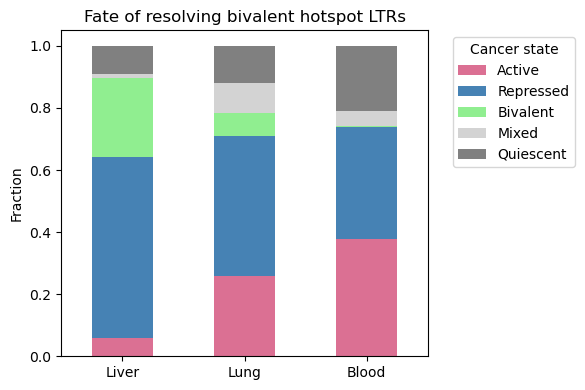

In [458]:
color_dict = {
    "Active": "palevioletred",
    "Repressed": "steelblue",
    "Bivalent": "lightgreen",
    "Mixed": "lightgray",
    "Quiescent": "gray"
}

plot_df = (
    biv_fate
    .pivot(index="tissue", columns="cancer_category", values="fraction")
    .reindex(["Liver", "Lung", "Blood"])
    .reindex(columns=category_order)
    .fillna(0)
)

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4),
    color=[color_dict[c] for c in category_order]
)

plt.ylabel("Fraction")
plt.xlabel("")
plt.title("Fate of resolving bivalent hotspot LTRs")
plt.xticks(rotation=0)
plt.legend(title="Cancer state", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [459]:
biv_fate.pivot(
    index="tissue",
    columns="cancer_category",
    values="count"
).reindex(["Liver", "Lung", "Blood"]).reindex(columns=category_order)

cancer_category,Active,Repressed,Bivalent,Mixed,Quiescent
tissue,,,,,
Liver,4,39,17,1,6
Lung,24,42,7,9,11
Blood,179,170,1,23,99


#### TSS analysis just for revisiting

In [284]:
# Prepare gene annotation by chromosome
# group genes by chromosome once
gene_by_chr = {
    chrom: sub.reset_index(drop=True)
    for chrom, sub in gene_df.groupby("chrom")
}

gene_name_col = "gene_name"

In [285]:
# Define nearest-TSS function for an interval
def find_nearest_tss(chrom, start, end):
    if chrom not in gene_by_chr:
        return pd.Series({
            "nearest_gene": None,
            "nearest_gene_strand": None,
            "nearest_tss": np.nan,
            "tss_distance": np.nan
        })

    sub = gene_by_chr[chrom]
    tss_array = sub["tss"].values

    # distance = 0 if TSS lies inside interval
    # otherwise distance to nearest edge
    dist = np.where(
        tss_array < start,
        start - tss_array,
        np.where(tss_array > end, tss_array - end, 0)
    )

    idx = dist.argmin()

    return pd.Series({
        "nearest_gene": sub.iloc[idx][gene_name_col],
        "nearest_gene_strand": sub.iloc[idx]["strand"],
        "nearest_tss": sub.iloc[idx]["tss"],
        "tss_distance": int(dist[idx])
    })

In [286]:
# Compute TSS distance once on unique loci
df_loci = df[["chrom", "start", "end", "name"]].drop_duplicates().copy()

tss_info = df_loci.apply(
    lambda row: find_nearest_tss(row["chrom"], row["start"], row["end"]),
    axis=1
)

df_loci_tss = pd.concat([df_loci.reset_index(drop=True), tss_info.reset_index(drop=True)], axis=1)

print(df_loci_tss.shape)
df_loci_tss.head()

(672545, 8)


,chrom,start,end,name,nearest_gene,nearest_gene_strand,nearest_tss,tss_distance
0,chr1,20948,23075,MLT1K,MIR6859-1,-,17436,3512
1,chr1,29693,31848,MLT1A,MIR1302-2,+,30365,0
2,chr1,29952,32131,MLT1A,MIR1302-2,+,30365,0
3,chr1,33564,35921,MLT1J2,FAM138A,-,36081,160
4,chr1,37255,40464,MLT1E1A-int,FAM138A,-,36081,1174


In [287]:
#  Merge TSS info back into full df
df = df.merge(
    df_loci_tss,
    on=["chrom", "start", "end", "name"],
    how="left"
)

print(df.shape)

(85363427, 35)


In [288]:
# Make TSS-distance bins
def tss_bin(dist):
    if pd.isna(dist):
        return np.nan
    elif dist == 0:
        return "0"
    elif dist <= 1000:
        return "1-1kb"
    elif dist <= 5000:
        return "1kb-5kb"
    elif dist <= 10000:
        return "5kb-10kb"
    elif dist <= 20000:
        return "10kb-20kb"
    else:
        return ">20kb"

df["tss_bin"] = df["tss_distance"].apply(tss_bin)

In [290]:
# Add TSS info into your resolving-hotspot subset
df_loci_tss["tss_bin"] = df_loci_tss["tss_distance"].apply(tss_bin)

df_resolving_tss = df_resolving.merge(
    df_loci_tss[["chrom", "start", "end", "name", "tss_distance", "nearest_gene", "tss_bin"]],
    on=["chrom", "start", "end", "name"],
    how="left"
)

print(df_resolving_tss.shape)
df_resolving_tss.head()

(17901, 12)


,chrom,start,end,name,hotspot_normal,category_normal,hotspot_cancer,category_cancer,tissue,tss_distance,nearest_gene,tss_bin
0,chr1,732909,735062,LTR41,True,Active,False,Active,Liver,43572,LOC100288069,>20kb
1,chr1,887956,890347,MSTD,True,Active,False,Active,Liver,11154,FAM41C,10kb-20kb
2,chr1,888927,890998,MLT1I,True,Active,False,Active,Liver,12125,FAM41C,10kb-20kb
3,chr1,1171049,1173409,MLT1D,True,Active,False,Bivalent,Liver,470,TTLL10,1-1kb
4,chr1,2351202,2353368,MLT1J,True,Active,False,Active,Liver,0,LOC100129534,0


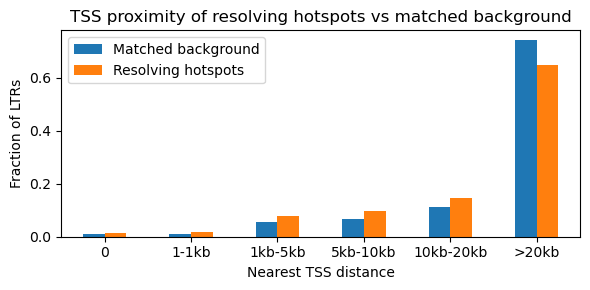

In [294]:
# Compare resolving hotspots vs matched normal background
normal_ids = ["E066", "E096", "E029"]   # Liver, Lung, Blood
bin_order = ["0", "1-1kb", "1kb-5kb", "5kb-10kb", "10kb-20kb", ">20kb"]

df_normal_bg = df[
    (df["cell_id"].isin(normal_ids))
].copy()

bg_frac = (
    df_normal_bg["tss_bin"]
    .value_counts(normalize=True)
    .reindex(bin_order, fill_value=0)
)

res_frac = (
    df_resolving_tss["tss_bin"]
    .value_counts(normalize=True)
    .reindex(bin_order, fill_value=0)
)

plot_df = pd.DataFrame({
    "Matched background": bg_frac,
    "Resolving hotspots": res_frac
})

ax = plot_df.plot(kind="bar", figsize=(6,3))
ax.set_ylabel("Fraction of LTRs")
ax.set_xlabel("Nearest TSS distance")
ax.set_title("TSS proximity of resolving hotspots vs matched background")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

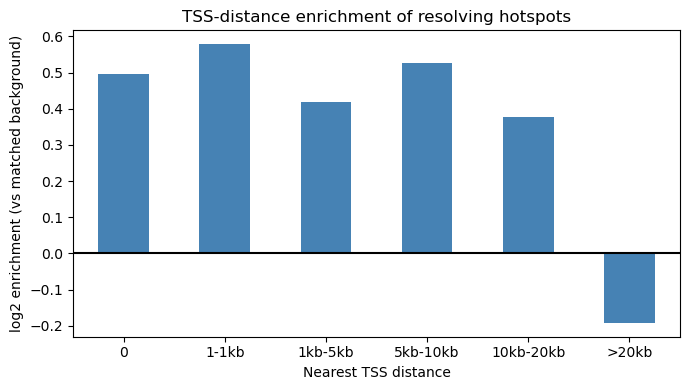

In [300]:
# TSS-distance enrichment plot
tss_enrichment = np.log2((res_frac + 1e-9) / (bg_frac + 1e-9))

plt.figure(figsize=(7,4))

tss_enrichment.plot(
    kind="bar",
    color="steelblue"
)

plt.axhline(0, color="black")
plt.ylabel("log2 enrichment (vs matched background)")
plt.xlabel("Nearest TSS distance")
plt.title("TSS-distance enrichment of resolving hotspots")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

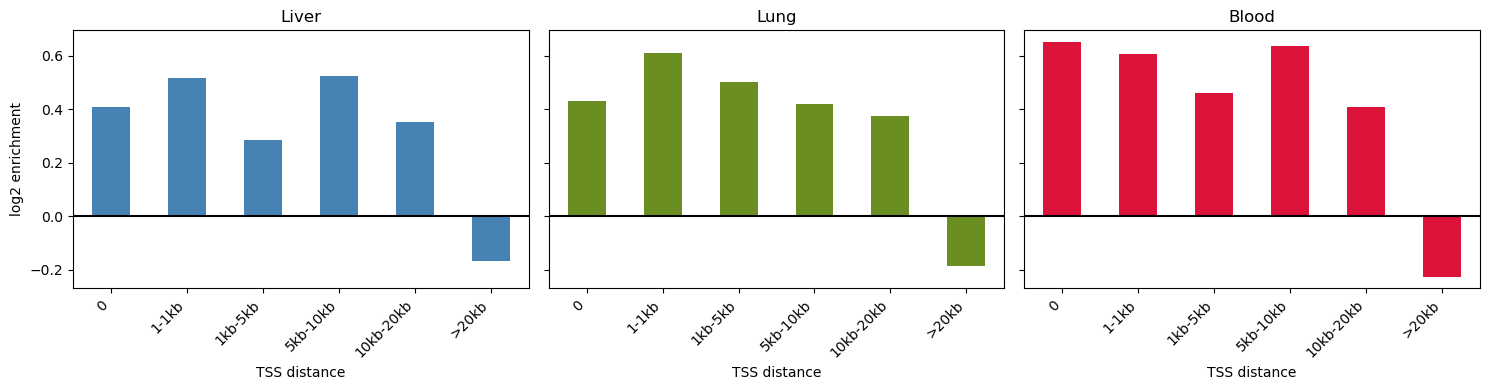

In [305]:
# Tissue-specific version
pair_map = {
    "Liver": "E066",
    "Lung": "E096",
    "Blood": "E029"
}

palette = {
    "Liver": "steelblue",
    "Lung": "olivedrab",
    "Blood": "crimson"
}

fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

for ax, (label, normal_id) in zip(axes, pair_map.items()):
    bg = (
        df[df["cell_id"] == normal_id]["tss_bin"]
        .value_counts(normalize=True)
        .reindex(bin_order, fill_value=0)
    )

    res_sub = df_resolving_tss[df_resolving_tss["tissue"] == label]
    res = (
        res_sub["tss_bin"]
        .value_counts(normalize=True)
        .reindex(bin_order, fill_value=0)
    )

    enrich = np.log2((res + 1e-9) / (bg + 1e-9))

    enrich.plot(kind="bar", ax=ax, color=palette[label])
    ax.axhline(0, color="black")
    ax.set_title(label)
    ax.set_xlabel("TSS distance")
    ax.set_xticklabels(bin_order, rotation=45, ha="right")

axes[0].set_ylabel("log2 enrichment")
plt.tight_layout()
plt.show()

#### Are hotspot LTRs enriched for CTCF overlap?

- Do hotspot LTRs overlap CTCF-bound regions more often than background LTRs?

In [ ]:
# Load merged CTCF file
ctcf = pd.read_csv(
    ctcf_merged,
    sep="\t",
    header=None,
    names=["chrom", "start", "end"]
)

In [ ]:
# Make unique LTR loci
df_loci = df[["chrom", "start", "end", "name"]].drop_duplicates().copy()

In [309]:
len(df_loci)

672545

In [310]:
# Mark overlap

def mark_ctcf_overlap(df_loci, ctcf):
    df_loci = df_loci.copy()

    ctcf_by_chr = {
        chrom: sub[["start", "end"]].values
        for chrom, sub in ctcf.groupby("chrom")
    }

    overlaps = []

    for _, row in df_loci.iterrows():
        chrom = row["chrom"]
        start = row["start"]
        end = row["end"]

        if chrom not in ctcf_by_chr:
            overlaps.append(False)
            continue

        arr = ctcf_by_chr[chrom]
        overlap = np.any((arr[:, 0] < end) & (arr[:, 1] > start))
        overlaps.append(overlap)

    df_loci["ctcf_overlap"] = overlaps
    return df_loci

df_loci = mark_ctcf_overlap(df_loci, ctcf)

In [312]:
df.head()

,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,frac_N,frac_O,state_seq_full_slice,is_hotspot,state_category,nearest_gene,nearest_gene_strand,nearest_tss,tss_distance,tss_bin
0,E001,False,chr1,20948,23075,MLT1K,2127,12,1.0,0,...,0.0,1.0,OOOOOOOOOOOO,False,Quiescent,MIR6859-1,-,17436,3512,1kb-5kb
1,E001,False,chr1,29693,31848,MLT1A,2155,12,1.0,0,...,0.0,1.0,OOOOOOOOOOOO,False,Quiescent,MIR1302-2,+,30365,0,0
2,E001,False,chr1,29952,32131,MLT1A,2179,12,1.0,0,...,0.0,1.0,OOOOOOOOOOOO,False,Quiescent,MIR1302-2,+,30365,0,0
3,E001,False,chr1,33564,35921,MLT1J2,2357,13,1.0,0,...,0.0,1.0,OOOOOOOOOOOOO,False,Quiescent,FAM138A,-,36081,160,1-1kb
4,E001,False,chr1,37255,40464,MLT1E1A-int,3209,17,1.0,0,...,0.0,1.0,OOOOOOOOOOOOOOOOO,False,Quiescent,FAM138A,-,36081,1174,1kb-5kb


In [313]:
len(df)

85363427

In [314]:
df = df.merge(
    df_loci[["chrom", "start", "end", "name", "ctcf_overlap"]],
    on=["chrom", "start", "end", "name"],
    how="left"
)

##### A. Normal hotspots vs matched background

In [317]:
normal_ids = ["E066", "E096", "E029"]

df_normal = df[df["cell_id"].isin(normal_ids)].copy()

bg_frac = df_normal["ctcf_overlap"].mean()
hotspot_frac = df_normal[df_normal["is_hotspot"]]["ctcf_overlap"].mean()

print("Matched normal background:", bg_frac)
print("Normal hotspots:", hotspot_frac)
print("log2 enrichment:", np.log2((hotspot_frac + 1e-9) / (bg_frac + 1e-9)))

Matched normal background: 0.06107200157814937
Normal hotspots: 0.08492078460958129
log2 enrichment: 0.47560656523309913


In [320]:
df_resolving.head()

,chrom,start,end,name,hotspot_normal,category_normal,hotspot_cancer,category_cancer,tissue
0,chr1,732909,735062,LTR41,True,Active,False,Active,Liver
1,chr1,887956,890347,MSTD,True,Active,False,Active,Liver
2,chr1,888927,890998,MLT1I,True,Active,False,Active,Liver
3,chr1,1171049,1173409,MLT1D,True,Active,False,Bivalent,Liver
4,chr1,2351202,2353368,MLT1J,True,Active,False,Active,Liver


##### B. Resolving hotspots vs all hotspots

In [318]:
df_resolving_ctcf = df_resolving.merge(
    df_loci[["chrom", "start", "end", "name", "ctcf_overlap"]],
    on=["chrom", "start", "end", "name"],
    how="left"
)

resolving_frac = df_resolving_ctcf["ctcf_overlap"].mean()
all_hotspot_frac = df_normal[df_normal["is_hotspot"]]["ctcf_overlap"].mean()

print("All normal hotspots:", all_hotspot_frac)
print("Resolving hotspots:", resolving_frac)
print("log2 enrichment:", np.log2((resolving_frac + 1e-9) / (all_hotspot_frac + 1e-9)))

All normal hotspots: 0.08492078460958129
Resolving hotspots: 0.08055415898553153
log2 enrichment: -0.07615862315333817


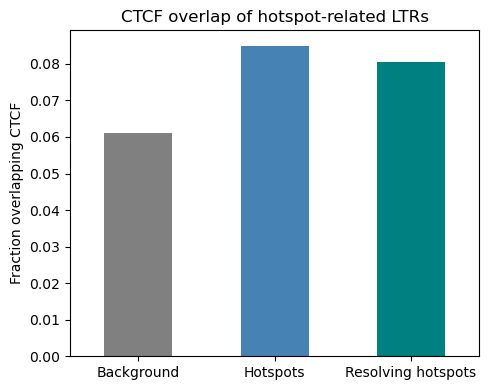

In [328]:
plot_df = pd.DataFrame({
    "group": ["Background", "Hotspots", "Resolving hotspots"],
    "fraction": [bg_frac, hotspot_frac, resolving_frac]
})

ax = plot_df.plot(kind="bar", x="group", y="fraction", legend=False, figsize=(5,4), color=["gray", "steelblue", "teal"])
ax.set_ylabel("Fraction overlapping CTCF")
ax.set_xlabel("")
ax.set_title("CTCF overlap of hotspot-related LTRs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Among distal LTRs only, are hotspots more likely to overlap CTCF than matched background?

In [330]:
#  Restrict to matched normal tissues and distal loci
normal_ids = ["E066", "E096", "E029"]  # liver, lung, blood

df_normal = df[df["cell_id"].isin(normal_ids)].copy()

# choose distal as >20kb
df_distal = df_normal[df_normal["tss_bin"] == ">20kb"].copy()

print(df_distal.shape)

(1497521, 37)


In [331]:
#  Compare distal hotspots vs distal background
bg_frac = df_distal["ctcf_overlap"].mean()

hotspot_frac = df_distal[df_distal["is_hotspot"] == True]["ctcf_overlap"].mean()

enrichment = np.log2((hotspot_frac + 1e-9) / (bg_frac + 1e-9))

print("Distal matched background:", bg_frac)
print("Distal hotspots:", hotspot_frac)
print("log2 enrichment:", enrichment)

Distal matched background: 0.049000982290064714
Distal hotspots: 0.06684907195149005
log2 enrichment: 0.44809685376726577


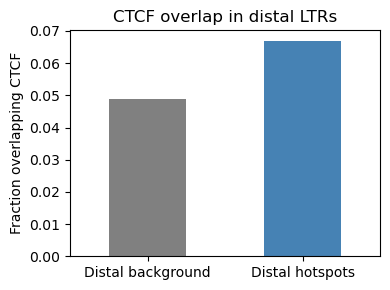

In [334]:
# Simple bar plot

plot_df = pd.DataFrame({
    "group": ["Distal background", "Distal hotspots"],
    "fraction": [bg_frac, hotspot_frac]
})

ax = plot_df.plot(kind="bar", x="group", y="fraction", legend=False, figsize=(4,3), color=["gray", "steelblue"])
ax.set_ylabel("Fraction overlapping CTCF")
ax.set_xlabel("")
ax.set_title("CTCF overlap in distal LTRs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [335]:
# Tissue-specific version

pair_map = {
    "Liver": "E066",
    "Lung": "E096",
    "Blood": "E029"
}

records = []

for tissue, normal_id in pair_map.items():
    sub = df[
        (df["cell_id"] == normal_id) &
        (df["tss_bin"] == ">20kb")
    ].copy()

    bg = sub["ctcf_overlap"].mean()
    hs = sub[sub["is_hotspot"] == True]["ctcf_overlap"].mean()

    records.append({
        "tissue": tissue,
        "background": bg,
        "hotspots": hs,
        "log2_enrichment": np.log2((hs + 1e-9) / (bg + 1e-9))
    })

distal_ctcf_df = pd.DataFrame(records)
print(distal_ctcf_df)

  tissue  background  hotspots  log2_enrichment
0  Liver    0.049001  0.062277         0.345884
1   Lung    0.049001  0.069905         0.512588
2  Blood    0.049001  0.069202         0.498005


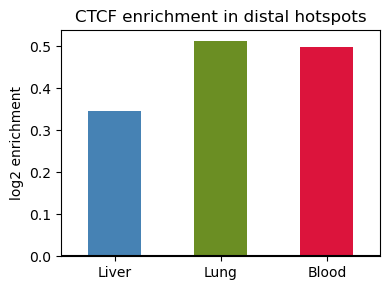

In [340]:
# Tissue-specific enrichment plot
ax = distal_ctcf_df.plot(
    kind="bar",
    x="tissue",
    y="log2_enrichment",
    legend=False,
    figsize=(4,3),
    color=["steelblue", "olivedrab", "crimson"]
)

plt.axhline(0, color="black")
ax.set_ylabel("log2 enrichment")
ax.set_xlabel("")
ax.set_title("CTCF enrichment in distal hotspots")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### Compare each hotspot category to matched background of the same category

In [341]:
normal_ids = ["E066", "E096", "E029"]  # liver, lung, blood

df_hotspot_normal = df[
    (df["cell_id"].isin(normal_ids)) &
    (df["is_hotspot"] == True)
].copy()

df_hotspot_normal["state_category"].value_counts()

state_category
Active       14977
Repressed     2156
Mixed         2003
Quiescent     1313
Bivalent       759
Name: count, dtype: int64

In [342]:
category_order = ["Active", "Repressed", "Bivalent", "Mixed", "Quiescent"]

ctcf_by_cat = (
    df_hotspot_normal
    .groupby("state_category")["ctcf_overlap"]
    .mean()
    .reindex(category_order)
)

count_by_cat = (
    df_hotspot_normal
    .groupby("state_category")
    .size()
    .reindex(category_order)
)

print(ctcf_by_cat)
print(count_by_cat)

state_category
Active       0.087200
Repressed    0.094156
Bivalent     0.067194
Mixed        0.072891
Quiescent    0.072353
Name: ctcf_overlap, dtype: float64
state_category
Active       14977
Repressed     2156
Bivalent       759
Mixed         2003
Quiescent     1313
dtype: int64


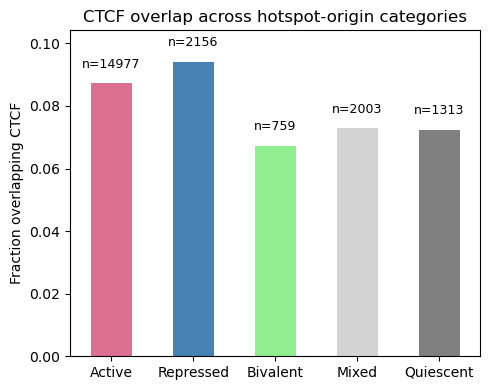

In [349]:
import matplotlib.pyplot as plt

color_dict = {
    "Active": "palevioletred",
    "Repressed": "steelblue",
    "Bivalent": "lightgreen",
    "Mixed": "lightgray",
    "Quiescent": "gray"
}

plt.figure(figsize=(5,4))
ax = ctcf_by_cat.plot(
    kind="bar",
    color=[color_dict[c] for c in ctcf_by_cat.index]
)

plt.ylabel("Fraction overlapping CTCF")
plt.xlabel("")
plt.title("CTCF overlap across hotspot-origin categories")
plt.xticks(rotation=0)

for i, (val, cnt) in enumerate(zip(ctcf_by_cat, count_by_cat)):
    if pd.notna(val):
        ax.text(i, val + 0.005, f"n={cnt}", ha="center", fontsize=9)
plt.ylim(0, ctcf_by_cat.max() + 0.01)
plt.tight_layout()
plt.show()

In [350]:
# Compute enrichment per category

records = []

for cat in category_order:
    sub_all = df[
        (df["cell_id"].isin(normal_ids)) &
        (df["state_category"] == cat)
    ].copy()

    sub_hot = sub_all[sub_all["is_hotspot"] == True].copy()

    if len(sub_all) == 0 or len(sub_hot) == 0:
        continue

    bg_frac = sub_all["ctcf_overlap"].mean()
    hot_frac = sub_hot["ctcf_overlap"].mean()

    records.append({
        "category": cat,
        "background_frac": bg_frac,
        "hotspot_frac": hot_frac,
        "log2_enrichment": np.log2((hot_frac + 1e-9) / (bg_frac + 1e-9)),
        "n_hotspot": len(sub_hot),
        "n_all": len(sub_all)
    })

ctcf_cat_enrich = pd.DataFrame(records)
print(ctcf_cat_enrich)

    category  background_frac  hotspot_frac  log2_enrichment  n_hotspot  \
0     Active         0.076330      0.087200         0.192091      14977   
1  Repressed         0.065475      0.094156         0.524116       2156   
2   Bivalent         0.064126      0.067194         0.067407        759   
3      Mixed         0.063536      0.072891         0.198153       2003   
4  Quiescent         0.055039      0.072353         0.394600       1313   

     n_all  
0   401430  
1   309540  
2     2152  
3    44148  
4  1260283  


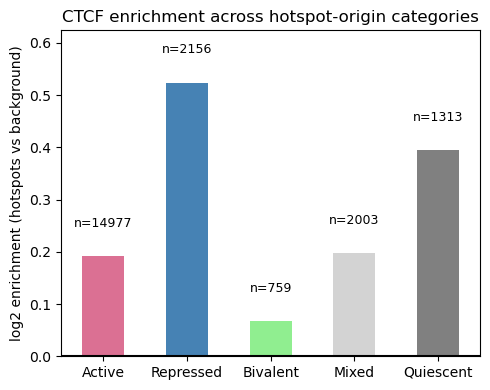

In [370]:
if "category" in ctcf_cat_enrich.columns:
    ctcf_cat_enrich = ctcf_cat_enrich.set_index("category")

ctcf_cat_enrich = ctcf_cat_enrich.reindex(category_order).dropna(how="all")

plt.figure(figsize=(5,4))
ax = ctcf_cat_enrich["log2_enrichment"].plot(
    kind="bar",
    color=[color_dict[c] for c in ctcf_cat_enrich.index]
)

plt.axhline(0, color="black")
plt.ylabel("log2 enrichment (hotspots vs background)")
plt.xlabel("")
plt.title("CTCF enrichment across hotspot-origin categories")
plt.xticks(rotation=0)

for i, (val, cnt) in enumerate(zip(ctcf_cat_enrich["log2_enrichment"], ctcf_cat_enrich["n_hotspot"])):
    ax.text(
        i,
        val + (0.05 if val >= 0 else -0.08),
        f"n={cnt}",
        ha="center",
        va="bottom" if val >= 0 else "top",
        fontsize=9
    )
plt.ylim(0, ctcf_cat_enrich["log2_enrichment"].max() + 0.1)
plt.tight_layout()
plt.show()

In [356]:
pair_map = {
    "Liver": "E066",
    "Lung": "E096",
    "Blood": "E029"
}

records = []

for tissue, cid in pair_map.items():
    for cat in category_order:
        sub_all = df[(df["cell_id"] == cid) & (df["state_category"] == cat)].copy()
        sub_hot = sub_all[sub_all["is_hotspot"] == True].copy()

        if len(sub_all) == 0 or len(sub_hot) == 0:
            continue

        bg_frac = sub_all["ctcf_overlap"].mean()
        hot_frac = sub_hot["ctcf_overlap"].mean()

        records.append({
            "tissue": tissue,
            "category": cat,
            "log2_enrichment": np.log2((hot_frac + 1e-9) / (bg_frac + 1e-9)),
            "n_hotspot": len(sub_hot)
        })

ctcf_cat_tissue = pd.DataFrame(records)
print(ctcf_cat_tissue)

   tissue   category  log2_enrichment  n_hotspot
0   Liver     Active         0.092116       6155
1   Liver  Repressed         0.531025        593
2   Liver   Bivalent         0.353120         97
3   Liver      Mixed        -0.229334        627
4   Liver  Quiescent         0.223081        358
5    Lung     Active         0.201712       4765
6    Lung  Repressed         0.298424        698
7    Lung   Bivalent         0.481489         99
8    Lung      Mixed         0.127739        692
9    Lung  Quiescent         0.442597        588
10  Blood     Active         0.325983       4057
11  Blood  Repressed         0.639803        865
12  Blood   Bivalent        -0.145497        563
13  Blood      Mixed         0.560000        684
14  Blood  Quiescent         0.471764        367


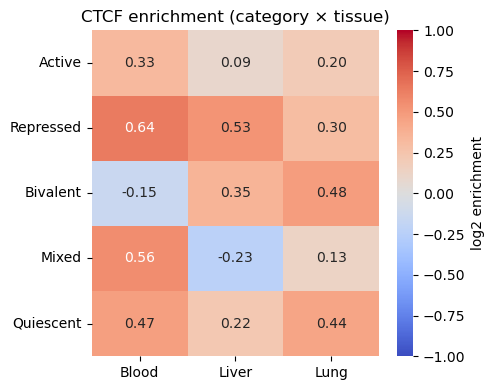

In [381]:
pivot = ctcf_cat_tissue.pivot(
    index="category",
    columns="tissue",
    values="log2_enrichment"
).reindex(category_order)

plt.figure(figsize=(5,4))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "log2 enrichment"}
)

plt.title("CTCF enrichment (category × tissue)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

### CpG and GC

In [384]:
records = []

for rec in SeqIO.parse(fasta_path, "fasta"):
    header = rec.id  # e.g. MLT1K::chr1:26213342-26215429
    seq = str(rec.seq).upper()

    m = re.match(r"(.+)::(chr[^:]+):(\d+)-(\d+)", header)
    if m is None:
        continue

    name, chrom, start, end = m.groups()
    start = int(start)
    end = int(end)

    valid_seq = "".join([b for b in seq if b in "ACGT"])
    valid_len = len(valid_seq)

    if valid_len == 0:
        gc = pd.NA
        cpg_density = pd.NA
        cpg_count = pd.NA
    else:
        gc = (valid_seq.count("G") + valid_seq.count("C")) / valid_len
        cpg_count = sum(
            1 for i in range(len(valid_seq) - 1)
            if valid_seq[i:i+2] == "CG"
        )
        cpg_density = cpg_count / valid_len

    records.append({
        "name": name,
        "chrom": chrom,
        "start": start,
        "end": end,
        "seq_len": len(seq),
        "valid_len": valid_len,
        "GC": gc,
        "CpG_count": cpg_count,
        "CpG_density": cpg_density,
        "N_fraction": 1 - valid_len / len(seq) if len(seq) > 0 else pd.NA
    })

seq_features = pd.DataFrame(records)
seq_features.head()

,name,chrom,start,end,seq_len,valid_len,GC,CpG_count,CpG_density,N_fraction
0,MSTA-int,chr1,159382130,159385355,3225,3225,0.378915,7,0.002171,0.0
1,HUERS-P3b-int,chr1,226491179,226493451,2272,2272,0.459067,21,0.009243,0.0
2,MLT1C,chr1,6290167,6292531,2364,2364,0.541878,49,0.020728,0.0
3,MLT1K,chr1,26213342,26215429,2087,2087,0.467178,28,0.013416,0.0
4,LTR5_Hs,chr1,29358332,29361290,2958,2958,0.453685,32,0.010818,0.0


In [385]:
df = df.merge(
    seq_features[["chrom", "start", "end", "name", "GC", "CpG_count", "CpG_density", "N_fraction"]],
    on=["chrom", "start", "end", "name"],
    how="left"
)

df[["GC", "CpG_density", "N_fraction"]].describe()

,GC,CpG_density,N_fraction
count,8.536343e+07,8.536343e+07,8.536343e+07
mean,4.127614e-01,8.269125e-03,3.988020e-05
std,4.910065e-02,5.273387e-03,3.586946e-03
min,1.107334e-01,0.000000e+00,0.000000e+00
25%,3.780229e-01,4.732608e-03,0.000000e+00
50%,4.101732e-01,6.875806e-03,0.000000e+00
75%,4.444037e-01,1.035822e-02,0.000000e+00
max,7.375415e-01,1.200759e-01,4.906771e-01


In [386]:
df.head()

,cell_id,is_cancer,chrom,start,end,name,length,n_bins,O_ratio,n_transitions,...,nearest_gene,nearest_gene_strand,nearest_tss,tss_distance,tss_bin,ctcf_overlap,GC,CpG_count,CpG_density,N_fraction
0,E001,False,chr1,20948,23075,MLT1K,2127,12,1.0,0,...,MIR6859-1,-,17436,3512,1kb-5kb,False,0.564645,44,0.020686,0.0
1,E001,False,chr1,29693,31848,MLT1A,2155,12,1.0,0,...,MIR1302-2,+,30365,0,0,False,0.472390,39,0.018097,0.0
2,E001,False,chr1,29952,32131,MLT1A,2179,12,1.0,0,...,MIR1302-2,+,30365,0,0,False,0.462598,28,0.012850,0.0
3,E001,False,chr1,33564,35921,MLT1J2,2357,13,1.0,0,...,FAM138A,-,36081,160,1-1kb,False,0.477302,26,0.011031,0.0
4,E001,False,chr1,37255,40464,MLT1E1A-int,3209,17,1.0,0,...,FAM138A,-,36081,1174,1kb-5kb,False,0.490184,34,0.010595,0.0


In [387]:
# 1. Hotspot vs non-hotspot
df_normal = df[df["cell_id"].isin(["E066","E096","E029"])]

bg_gc = df_normal["GC"].mean()
hs_gc = df_normal[df_normal["is_hotspot"]]["GC"].mean()

bg_cpg = df_normal["CpG_density"].mean()
hs_cpg = df_normal[df_normal["is_hotspot"]]["CpG_density"].mean()

print(bg_gc, hs_gc)
print(bg_cpg, hs_cpg)

0.4127609472450614 0.4267283831697153
0.008269080311392254 0.00963921864197652


In [388]:
# 2. Category-level 
df_hotspot = df_normal[df_normal["is_hotspot"]]

df_hotspot.groupby("state_category")[["GC","CpG_density"]].mean()

,GC,CpG_density
state_category,,
Active,0.428056,0.009825
Bivalent,0.427621,0.009477
Mixed,0.422806,0.009084
Quiescent,0.415803,0.008172
Repressed,0.427489,0.009812


/var/folders/13/_k644pzx7fx6m400h0j14_0h0000gn/T/ipykernel_67753/1600485917.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


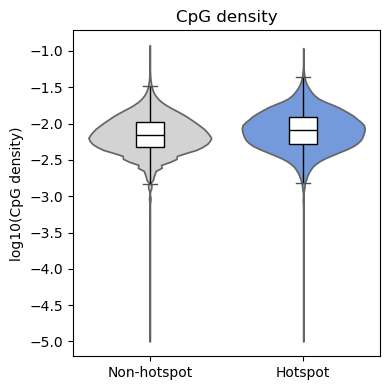

In [395]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df_normal.copy()
plot_df["group"] = plot_df["is_hotspot"].map({
    False: "Non-hotspot",
    True: "Hotspot"
})

# log transform to handle long tail
plot_df["log_CpG_density"] = np.log10(plot_df["CpG_density"] + 1e-5)

plt.figure(figsize=(4,4))

sns.violinplot(
    data=plot_df,
    x="group",
    y="log_CpG_density",
    inner=None,
    cut=0,
    palette=["lightgray", "cornflowerblue"]
)

sns.boxplot(
    data=plot_df,
    x="group",
    y="log_CpG_density",
    width=0.18,
    showcaps=True,
    boxprops={"facecolor": "white", "edgecolor": "black"},
    whiskerprops={"color": "black"},
    medianprops={"color": "black"},
    showfliers=False
)

plt.ylabel("log10(CpG density)")
plt.xlabel("")
plt.title("CpG density")

plt.tight_layout()
plt.show()

### Hotspot LTRs represent loci of chromatin instability that are not captured by simple genomic or sequence-level features. Ugh...

#### Why 4 as a threshold for hotspot definition, BTW


In [64]:
import numpy as np
import pandas as pd

thresholds = [2, 3, 4, 5, 6]

records = []

for tissue, (normal_id, cancer_id) in pairs.items():
    df_n = df[df["cell_id"] == normal_id].copy()
    df_c = df[df["cell_id"] == cancer_id].copy()

    merged = df_n.merge(
        df_c,
        on=["chrom", "start", "end", "name"],
        suffixes=("_normal", "_cancer")
    )

    for t in thresholds:
        merged["hotspot_normal"] = merged["n_transitions_normal"] >= t
        merged["hotspot_cancer"] = merged["n_transitions_cancer"] >= t

        sub = merged[merged["hotspot_normal"] == True]

        if len(sub) == 0:
            continue

        frac_resolve = (sub["hotspot_cancer"] == False).mean()
        frac_persist = (sub["hotspot_cancer"] == True).mean()

        records.append({
            "tissue": tissue,
            "threshold": t,
            "resolve": frac_resolve,
            "persist": frac_persist
        })

df_robust = pd.DataFrame(records)

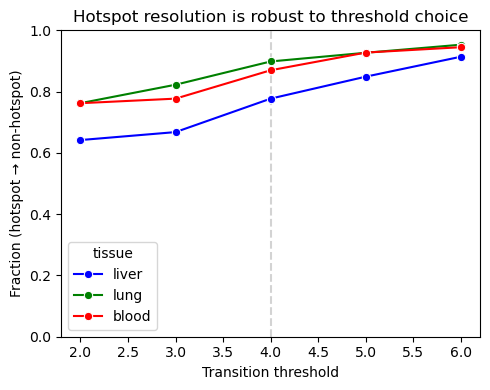

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    "liver": "blue",
    "lung": "green",
    "blood": "red"
}

plt.figure(figsize=(5,4))
plt.axvline(4, linestyle="--", color="lightgray")

sns.lineplot(
    data=df_robust,
    x="threshold",
    y="resolve",
    hue="tissue",
    marker="o",
    palette=palette 
)

plt.ylabel("Fraction (hotspot → non-hotspot)")
plt.xlabel("Transition threshold")
plt.title("Hotspot resolution is robust to threshold choice")

plt.ylim(0,1)
plt.tight_layout()
plt.show()

Highly dynamic (high-transition) chromatin regions are intrinsically unstable and preferentially collapse into more stable states in cancer.


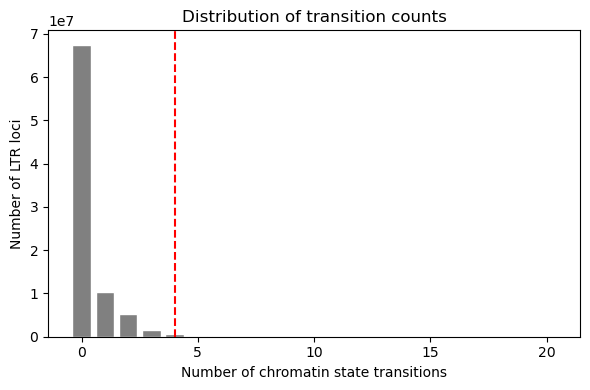

In [93]:
counts = df["n_transitions"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.axvline(4, color="red", linestyle="--")

plt.bar(counts.index, counts.values, color="gray", edgecolor="white")

plt.xlabel("Number of chromatin state transitions")
plt.ylabel("Number of LTR loci")
plt.title("Distribution of transition counts")

plt.tight_layout()
plt.show()

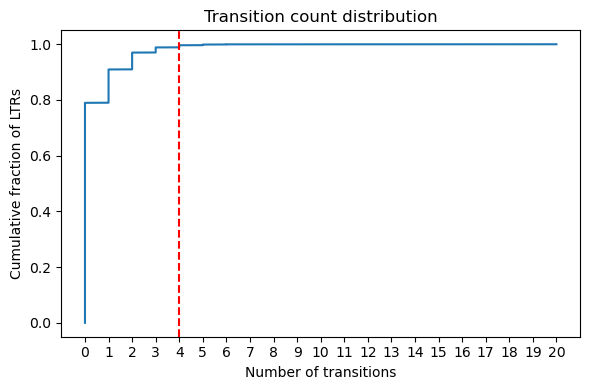

In [92]:
import numpy as np

sorted_vals = np.sort(df["n_transitions"])
cdf = np.arange(len(sorted_vals)) / len(sorted_vals)

plt.figure(figsize=(6,4))
plt.plot(sorted_vals, cdf)

plt.axvline(4, color="red", linestyle="--")

plt.xlabel("Number of transitions")
plt.xticks(range(0, df["n_transitions"].max()+1))
plt.ylabel("Cumulative fraction of LTRs")
plt.title("Transition count distribution")

plt.tight_layout()
plt.show()

In [465]:
df.columns

Index(['cell_id', 'is_cancer', 'chrom', 'start', 'end', 'name', 'length',
       'n_bins', 'O_ratio', 'n_transitions', 'transition_density',
       'n_unique_states', 'entropy', 'frac_A', 'frac_B', 'frac_C', 'frac_D',
       'frac_E', 'frac_F', 'frac_G', 'frac_H', 'frac_I', 'frac_J', 'frac_K',
       'frac_L', 'frac_M', 'frac_N', 'frac_O', 'state_seq_full_slice',
       'is_hotspot', 'state_category', 'nearest_gene', 'nearest_gene_strand',
       'nearest_tss', 'tss_distance', 'tss_bin', 'ctcf_overlap', 'GC',
       'CpG_count', 'CpG_density', 'N_fraction'],
      dtype='object')

##### Okay,, just take a look at the active->repressed, repressed->active for a bit..

In [ ]:
df_pairs_all = []

for tissue, (normal_id, cancer_id) in pairs.items():
    sub_normal = df[df2["cell_id"] == normal_id]
    sub_cancer = df[df2["cell_id"] == cancer_id]

    merged = sub_normal.merge(
        sub_cancer,
        on=["chrom", "start", "end", "name"],
        suffixes=("_normal", "_cancer")
    )
    
    merged["tissue"] = tissue
    df_pairs_all.append(merged)

df_pairs_all = pd.concat(df_pairs_all, ignore_index=True)

In [470]:
df_pairs_all["transition"] = (
    df_pairs_all["state_category_normal"] 
    + "→" + 
    df_pairs_all["state_category_cancer"]
)

transitions_of_interest = [
    "Active→Repressed",
    "Repressed→Active"
]

df_switch = df_pairs_all[
    df_pairs_all["transition"].isin(transitions_of_interest)
].copy()

pd.crosstab(
    df_pairs_all["tissue"],
    df_pairs_all["transition"]
)



transition,Active→Active,Active→Bivalent,Active→Mixed,Active→Quiescent,Active→Repressed,Bivalent→Active,Bivalent→Bivalent,Bivalent→Mixed,Bivalent→Quiescent,Bivalent→Repressed,...,Quiescent→Active,Quiescent→Bivalent,Quiescent→Mixed,Quiescent→Quiescent,Quiescent→Repressed,Repressed→Active,Repressed→Bivalent,Repressed→Mixed,Repressed→Quiescent,Repressed→Repressed
tissue,,,,,,,,,,,,,,,,,,,,,
Blood,78209,11,1215,30398,12012,581,15,81,291,460,...,31297,12,3227,337779,48906,10247,17,1413,65147,26307
Liver,99032,2206,2240,26843,11169,26,123,14,20,230,...,29858,884,6163,240048,98106,5135,504,2395,69473,65160
Lung,91297,200,1637,37381,7279,69,29,21,42,150,...,32546,47,5039,341016,78230,4436,107,1162,31623,26070


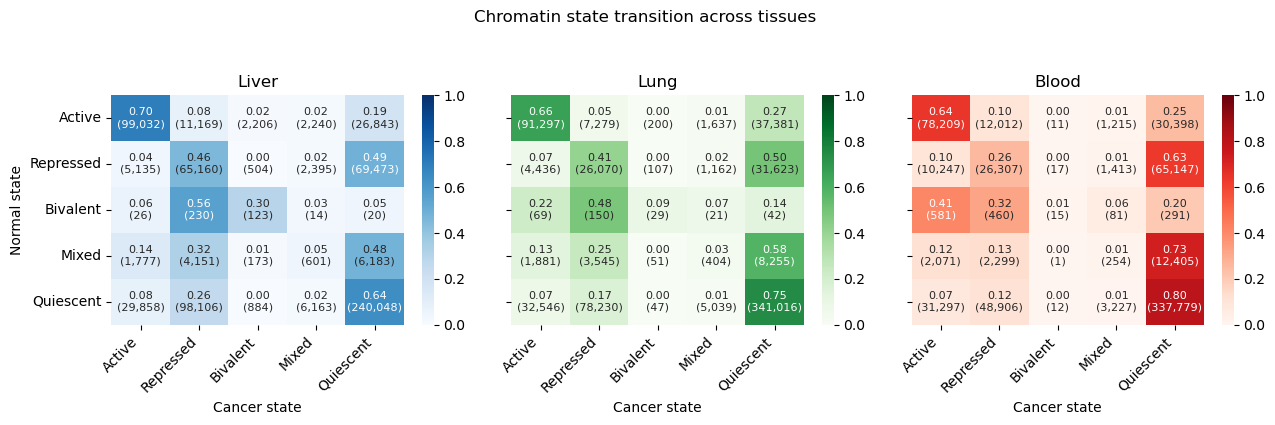

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

crosstab_df = pd.crosstab(
    df_pairs_all["tissue"],
    df_pairs_all["transition"]
)

df_crosstab = crosstab_df.copy()

order = ["Active", "Repressed", "Bivalent", "Mixed", "Quiescent"]

cmap_dict = {
    "Liver": "Blues",
    "Lung": "Greens",
    "Blood": "Reds"
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, tissue in zip(axes, ["Liver", "Lung", "Blood"]):
    
    df_t = df_crosstab.loc[tissue].reset_index()
    df_t.columns = ["transition", "count"]
    df_t[["from", "to"]] = df_t["transition"].str.split("→", expand=True)

    # raw count matrix
    count_mat = (
        df_t.pivot(index="from", columns="to", values="count")
        .fillna(0)
        .reindex(index=order, columns=order, fill_value=0)
    )

    # row-normalized probability matrix
    prob_mat = count_mat.div(count_mat.sum(axis=1), axis=0).fillna(0)

    # annotation: probability + count
    annot_text = prob_mat.copy().astype(str)

    for i in range(prob_mat.shape[0]):
        for j in range(prob_mat.shape[1]):
            prob = prob_mat.iloc[i, j]
            count = count_mat.iloc[i, j]
            annot_text.iloc[i, j] = f"{prob:.2f}\n({int(count):,})"

    sns.heatmap(
        prob_mat,
        ax=ax,
        cmap=cmap_dict[tissue],
        annot=annot_text,
        fmt="",          # important for custom text
        vmin=0,
        vmax=1,
        cbar=True,
        annot_kws={"size": 8}
    )

    ax.set_title(tissue)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("Cancer state")
    if ax == axes[0]:
        ax.set_ylabel("Normal state")
    else:
        ax.set_ylabel("")

plt.suptitle("Chromatin state transition across tissues", y=1.05)
plt.tight_layout()
plt.show()

In [490]:

def plot_state_sankey(df_pairs_all, tissue="Liver", min_count=1000):
    order = ["Active", "Repressed", "Bivalent", "Mixed", "Quiescent"]

    sub = df_pairs_all[df_pairs_all["tissue"] == tissue].copy()

    trans_counts = (
        sub.groupby(["state_category_normal", "state_category_cancer"])
        .size()
        .reset_index(name="count")
    )

    trans_counts = trans_counts[trans_counts["count"] >= min_count].copy()

    # left nodes = normal states, right nodes = cancer states
    left_nodes = [f"Normal: {s}" for s in order]
    right_nodes = [f"Cancer: {s}" for s in order]
    labels = left_nodes + right_nodes

    label_to_idx = {label: i for i, label in enumerate(labels)}

    # sources = trans_counts["state_category_normal"].map(
    #     lambda x: label_to_idx[f"Normal: {x}"]
    # )
    # targets = trans_counts["state_category_cancer"].map(
    #     lambda x: label_to_idx[f"Cancer: {x}"]
    # )
    sources = trans_counts["state_category_normal"].map(
    lambda x: label_to_idx[f"Normal: {x}"]
    )

    targets = trans_counts["state_category_cancer"].map(
        lambda x: label_to_idx[f"Cancer: {x}"]
    )
    targets = targets + len(order)  # shift cancer nodes to right side

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=18,
            line=dict(color="black", width=0.4),
            label=labels,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=trans_counts["count"],
            customdata=trans_counts["count"],
            hovertemplate="%{source.label} → %{target.label}<br>n=%{customdata:,}<extra></extra>"
        )
    )])

    fig.update_layout(
        title_text=f"Chromatin state transition network ({tissue})",
        font_size=11,
        width=800,
        height=500
    )

    fig.show()

In [491]:
plot_state_sankey(df_pairs_all, tissue="Liver", min_count=100)
plot_state_sankey(df_pairs_all, tissue="Lung", min_count=100)
plot_state_sankey(df_pairs_all, tissue="Blood", min_count=100)

In [583]:

def plot_state_sankey_clean(df_pairs_all, tissue="Liver", min_count=100, y_pos_left=None, y_pos_right=None):
    order = ["Active", "Repressed", "Bivalent", "Mixed", "Quiescent"]

    color_dict = {
        "Active": "palevioletred",
        "Repressed": "steelblue",
        "Bivalent": "lightgreen",
        "Mixed": "lightgray",
        "Quiescent": "gray"
    }

    sub = df_pairs_all[df_pairs_all["tissue"] == tissue].copy()

    trans_counts = (
        sub.groupby(["state_category_normal", "state_category_cancer"])
        .size()
        .reset_index(name="count")
    )

    # keep order + remove tiny flows
    trans_counts = trans_counts[
        (trans_counts["state_category_normal"].isin(order)) &
        (trans_counts["state_category_cancer"].isin(order)) &
        (trans_counts["count"] >= min_count)
    ].copy()

    # fixed left/right nodes
    left_nodes = [f"Normal: {s}" for s in order]
    right_nodes = [f"Cancer: {s}" for s in order]
    labels = left_nodes + right_nodes

    label_to_idx = {label: i for i, label in enumerate(labels)}

    sources = trans_counts["state_category_normal"].map(
        lambda x: label_to_idx[f"Normal: {x}"]
    )

    targets = trans_counts["state_category_cancer"].map(
        lambda x: label_to_idx[f"Cancer: {x}"]
    )

    # node colors: same color for same state on both sides
    node_colors = [color_dict[s] for s in order] + [color_dict[s] for s in order]

    # link color: neutral gray with transparency
    link_colors = ["rgba(150,150,150,0.22)"] * len(trans_counts)

    if y_pos_left is None:
        y_pos_left = [0.02, 0.18, 0.30, 0.42, 0.70]
    if y_pos_right is None:
        y_pos_right = [0.02, 0.18, 0.30, 0.42, 0.70]

    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=40,
            thickness=12,
            line=dict(color="white", width=0.4),
            label=labels,
            color=node_colors,
            x=[0.02]*len(order) + [0.98]*len(order),
            y=y_pos_left + y_pos_right   # left + right
        ),
        link=dict(
            source=sources,
            target=targets,
            value=trans_counts["count"],
            color=link_colors,
            hovertemplate="%{source.label} → %{target.label}<br>n=%{value:,}<extra></extra>"
        )
    )])

    fig.update_layout(
        title=f"Chromatin state transition (Normal → Cancer): {tissue}",
        font_size=12,
        width=700,
        height=550
    )

    fig.show()

In [586]:
plot_state_sankey_clean(df_pairs_all, tissue="Liver", min_count=100,)
plot_state_sankey_clean(df_pairs_all, tissue="Lung", min_count=100)

In [585]:
plot_state_sankey_clean(df_pairs_all, tissue="Blood", min_count=100, y_pos_left=[0.02, 0.16, 0.31, 0.4, 0.7],
    y_pos_right=[0.02, 0.16, 0.24, 0.5, 0.8])

In [587]:
df_pairs_all.head()

,cell_id_normal,is_cancer_normal,chrom,start,end,name,length_normal,n_bins_normal,O_ratio_normal,n_transitions_normal,...,nearest_tss_cancer,tss_distance_cancer,tss_bin_cancer,ctcf_overlap_cancer,GC_cancer,CpG_count_cancer,CpG_density_cancer,N_fraction_cancer,tissue,transition
0,E066,False,chr1,20948,23075,MLT1K,2127,12,1.0,0,...,17436,3512,1kb-5kb,False,0.564645,44,0.020686,0.0,Liver,Quiescent→Quiescent
1,E066,False,chr1,29693,31848,MLT1A,2155,12,1.0,0,...,30365,0,0,False,0.472390,39,0.018097,0.0,Liver,Quiescent→Quiescent
2,E066,False,chr1,29952,32131,MLT1A,2179,12,1.0,0,...,30365,0,0,False,0.462598,28,0.012850,0.0,Liver,Quiescent→Quiescent
3,E066,False,chr1,33564,35921,MLT1J2,2357,13,1.0,0,...,36081,160,1-1kb,False,0.477302,26,0.011031,0.0,Liver,Quiescent→Quiescent
4,E066,False,chr1,37255,40464,MLT1E1A-int,3209,17,1.0,0,...,36081,1174,1kb-5kb,False,0.490184,34,0.010595,0.0,Liver,Quiescent→Quiescent


In [588]:
len(df_pairs_all)

2009686

In [592]:
df_pairs_all.columns

Index(['cell_id_normal', 'is_cancer_normal', 'chrom', 'start', 'end', 'name',
       'length_normal', 'n_bins_normal', 'O_ratio_normal',
       'n_transitions_normal', 'transition_density_normal',
       'n_unique_states_normal', 'entropy_normal', 'frac_A_normal',
       'frac_B_normal', 'frac_C_normal', 'frac_D_normal', 'frac_E_normal',
       'frac_F_normal', 'frac_G_normal', 'frac_H_normal', 'frac_I_normal',
       'frac_J_normal', 'frac_K_normal', 'frac_L_normal', 'frac_M_normal',
       'frac_N_normal', 'frac_O_normal', 'state_seq_full_slice_normal',
       'is_hotspot_normal', 'state_category_normal', 'nearest_gene_normal',
       'nearest_gene_strand_normal', 'nearest_tss_normal',
       'tss_distance_normal', 'tss_bin_normal', 'ctcf_overlap_normal',
       'GC_normal', 'CpG_count_normal', 'CpG_density_normal',
       'N_fraction_normal', 'cell_id_cancer', 'is_cancer_cancer',
       'length_cancer', 'n_bins_cancer', 'O_ratio_cancer',
       'n_transitions_cancer', 'transition_de

In [591]:
df_pairs_all["cell_id_normal"].value_counts()

cell_id_normal
E096    672517
E066    672514
E029    664655
Name: count, dtype: int64